# Kidney CT Disease Classification & Clinical Safety Pipeline

## Project Overview
This project develops an end-to-end deep learning pipeline that classifies a **kidney CT slice** into four diagnostic categories: **Cyst, Normal, Stone, and Tumor**.

The data is the *CT KIDNEY DATASET: Normal-Cyst-Tumor and Stone* (Islam et al., *Scientific Reports* 2022): 12,446 axial and coronal slices from hospital PACS systems in Dhaka, Bangladesh, each finding verified by a radiologist. Like the lung X-ray and heart ECG modules, the notebook is built around **clinical safety and explainability**:

* **Leakage-free evaluation:** The published images are consecutive slices of about 190 CT scans; neighbouring slices are near-identical (pixel correlation ≈ 0.998). Most published results on this dataset use a random image split and report ~99–100% accuracy. Here, exact duplicates are removed and **whole scan series** are assigned to train, validation or test, so the test set contains only scans the model has never seen.
* **Transfer Learning:** Two-phase training (head warm-up, then **full** fine-tuning with AdamW, label smoothing and strong augmentation) of **ConvNeXtTiny, EfficientNetV2B0, DenseNet121 and ResNet50V2** against a Custom CNN baseline, each with the input scaling its ImageNet weights expect.
* **Ensemble Methods:** A soft-voting ensemble across the pre-trained models.
* **Explainable AI (XAI):** **Grad-CAM heatmaps** to check that predictions come from the kidneys, not the scanner table, body outline or other organs.
* **Clinical Safety Layer:** An Out-of-Distribution (OOD) gate that rejects inputs that are not abdominal CT slices (Isolation Forest vs nearest-neighbour, chosen on validation data), plus a confidence threshold that flags uncertain cases for radiologist review.

# Import Libraries

In [1]:
import os
# Keras 3 runs on the PyTorch backend here: TensorFlow has no GPU support on native Windows,
# PyTorch does. This must be set before keras is imported.
os.environ['KERAS_BACKEND'] = 'torch'

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)   # third-party deprecation notices

import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import keras
from keras import layers

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, roc_auc_score, log_loss)

SEED = 42
keras.utils.set_random_seed(SEED)   # seeds Python, NumPy and PyTorch

# Faster GPU kernels: cuDNN autotuning and TF32 matrix maths
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'
print(f"Keras {keras.__version__} | backend: {keras.backend.backend()} | device: {device_name}")
print("Libraries imported successfully!")

Keras 3.14.1 | backend: torch | device: NVIDIA GeForce RTX 5060
Libraries imported successfully!


In [2]:
# Project folders (the notebook runs from models/kidney/image_based/notebooks/)
base_dir = Path('../data')
train_dir = base_dir / 'train'
val_dir = base_dir / 'val'
test_dir = base_dir / 'test'

MODELS_DIR = Path('../models')
IMAGES_DIR = Path('../images')
RESULTS_DIR = Path('../results')
for d in (MODELS_DIR, IMAGES_DIR, RESULTS_DIR):
    d.mkdir(exist_ok=True)

class_names = [
    'Cyst',
    'Normal',
    'Stone',
    'Tumor'
]
num_classes = len(class_names)

for path_name, dir_path in zip(['Train', 'Test', 'Validation'], [train_dir, test_dir, val_dir]):
    if dir_path.exists():
        print(f"✅ {path_name} directory found.")
    else:
        print(f"❌ {path_name} directory NOT found. Run `python data/build_kidney_dataset.py` first.")

✅ Train directory found.
✅ Test directory found.
✅ Validation directory found.


# Dataset Audit (Duplicates & Scan-Level Leakage)

### Why a Random Split Would Be Misleading
The 12,446 files are numbered in acquisition order, and consecutively numbered files are **adjacent slices of the same CT scan**. Two neighbouring slices differ by a few millimetres and are almost pixel-identical. A random image split puts slice *n* in the training set and slice *n+1* in the test set, so the test mostly measures recognition of scans already seen during training.

`data/build_kidney_dataset.py` therefore:
1. Removes **517 exact duplicate** images (425 of them in Cyst).
2. Groups the remaining 11,929 slices into **scan series**: runs of consecutive IDs that look alike, merged with any other near-identical slice.
3. Assigns whole series to train / validation / test (~70 / 15 / 15 per class, at least 3 series per class in each split).
4. Pads every slice to a square (black, the CT background) and stores it as 256×256 grayscale.

In [3]:
manifest = pd.read_csv(base_dir / 'manifest.csv')
manifest['n_copies'] = manifest['duplicates'].fillna('').apply(lambda s: len(s.split(';')) if s else 0)

audit = manifest.groupby('label').agg(unique_slices=('md5', 'size'),
                                      duplicate_files=('n_copies', 'sum'),
                                      scan_series=('series_id', 'nunique'))
audit.insert(0, 'raw_files', audit['unique_slices'] + audit['duplicate_files'])
audit['slices_per_series'] = (audit['unique_slices'] / audit['scan_series']).round(1)
audit.loc['Total'] = audit.sum(numeric_only=True)
audit.loc['Total', 'slices_per_series'] = round(audit.loc['Total', 'unique_slices'] / audit.loc['Total', 'scan_series'], 1)
display(audit.astype({c: int for c in ['raw_files', 'unique_slices', 'duplicate_files', 'scan_series']}))

series_split = pd.crosstab(manifest.drop_duplicates('series_id')['label'], manifest.drop_duplicates('series_id')['split'])
print("\nScan series per split (no series appears in two splits):")
display(series_split[['train', 'val', 'test']])

,raw_files,unique_slices,duplicate_files,scan_series,slices_per_series
label,,,,,
Cyst,3709,3284,425,64,51.3
Normal,5077,5002,75,47,106.4
Stone,1377,1360,17,55,24.7
Tumor,2283,2283,0,23,99.3
Total,12446,11929,517,189,63.1



Scan series per split (no series appears in two splits):


split,train,val,test
label,,,
Cyst,38,14,12
Normal,32,7,8
Stone,38,5,12
Tumor,15,4,4


### Demonstrating the Leakage
The simplest possible classifier makes the problem visible: a **1-nearest-neighbour** classifier on 32×32 thumbnails, which only "memorises" training images. On a random image split it looks excellent. On the series split used in this notebook it drops sharply, because it can no longer find a near-copy of each test slice in the training set.

1-NN on 32x32 thumbnails | random image split: 1.000 | scan-series split: 0.454


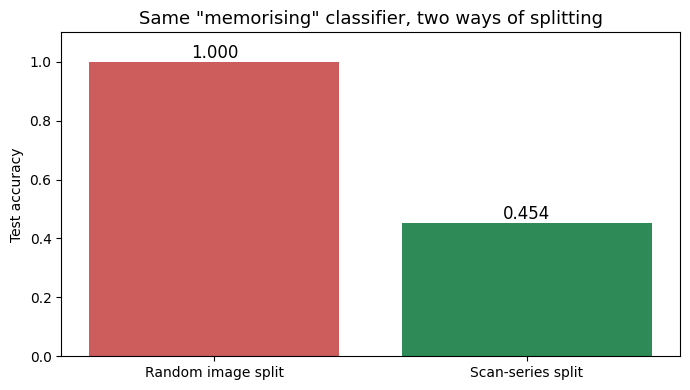

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

thumbs = np.stack([np.asarray(Image.open(base_dir / f).resize((32, 32), Image.BOX), np.float32).ravel() / 255
                   for f in manifest['file']])
labels = manifest['label'].map({c: i for i, c in enumerate(class_names)}).values

# (a) Random image-level split, as used by most published work on this dataset
tr, te = train_test_split(np.arange(len(labels)), test_size=0.15, stratify=labels, random_state=SEED)
knn = KNeighborsClassifier(n_neighbors=1).fit(thumbs[tr], labels[tr])
acc_random = accuracy_score(labels[te], knn.predict(thumbs[te]))

# (b) Scan-series split used in this notebook
tr = np.where(manifest['split'] == 'train')[0]
te = np.where(manifest['split'] == 'test')[0]
knn = KNeighborsClassifier(n_neighbors=1).fit(thumbs[tr], labels[tr])
acc_series = accuracy_score(labels[te], knn.predict(thumbs[te]))

print(f"1-NN on 32x32 thumbnails | random image split: {acc_random:.3f} | scan-series split: {acc_series:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Random image split', 'Scan-series split'], [acc_random, acc_series], color=['indianred', 'seagreen'])
ax.bar_label(bars, fmt='%.3f', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test accuracy')
ax.set_title('Same "memorising" classifier, two ways of splitting', fontsize=13)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'leakage_demo.png', dpi=120, bbox_inches='tight')
plt.show()

* **Random image split: 100.0%.** A classifier that only looks up the most similar training thumbnail is *perfect*, because every test slice has a near-identical neighbouring slice from the same scan in the training set. This is why published results on this dataset commonly reach 99–100%.
* **Scan-series split: 45.4%.** The same classifier falls to little better than always answering "Normal" (42% of test slices) once whole scans are held out.
* Every number reported below comes from the **scan-series split**: it measures performance on **patients' scans the model has never seen**, which is what matters clinically. Expect it to be well below the ~99% figures in the literature. Those figures mostly measure memorisation.

# Image Visualization

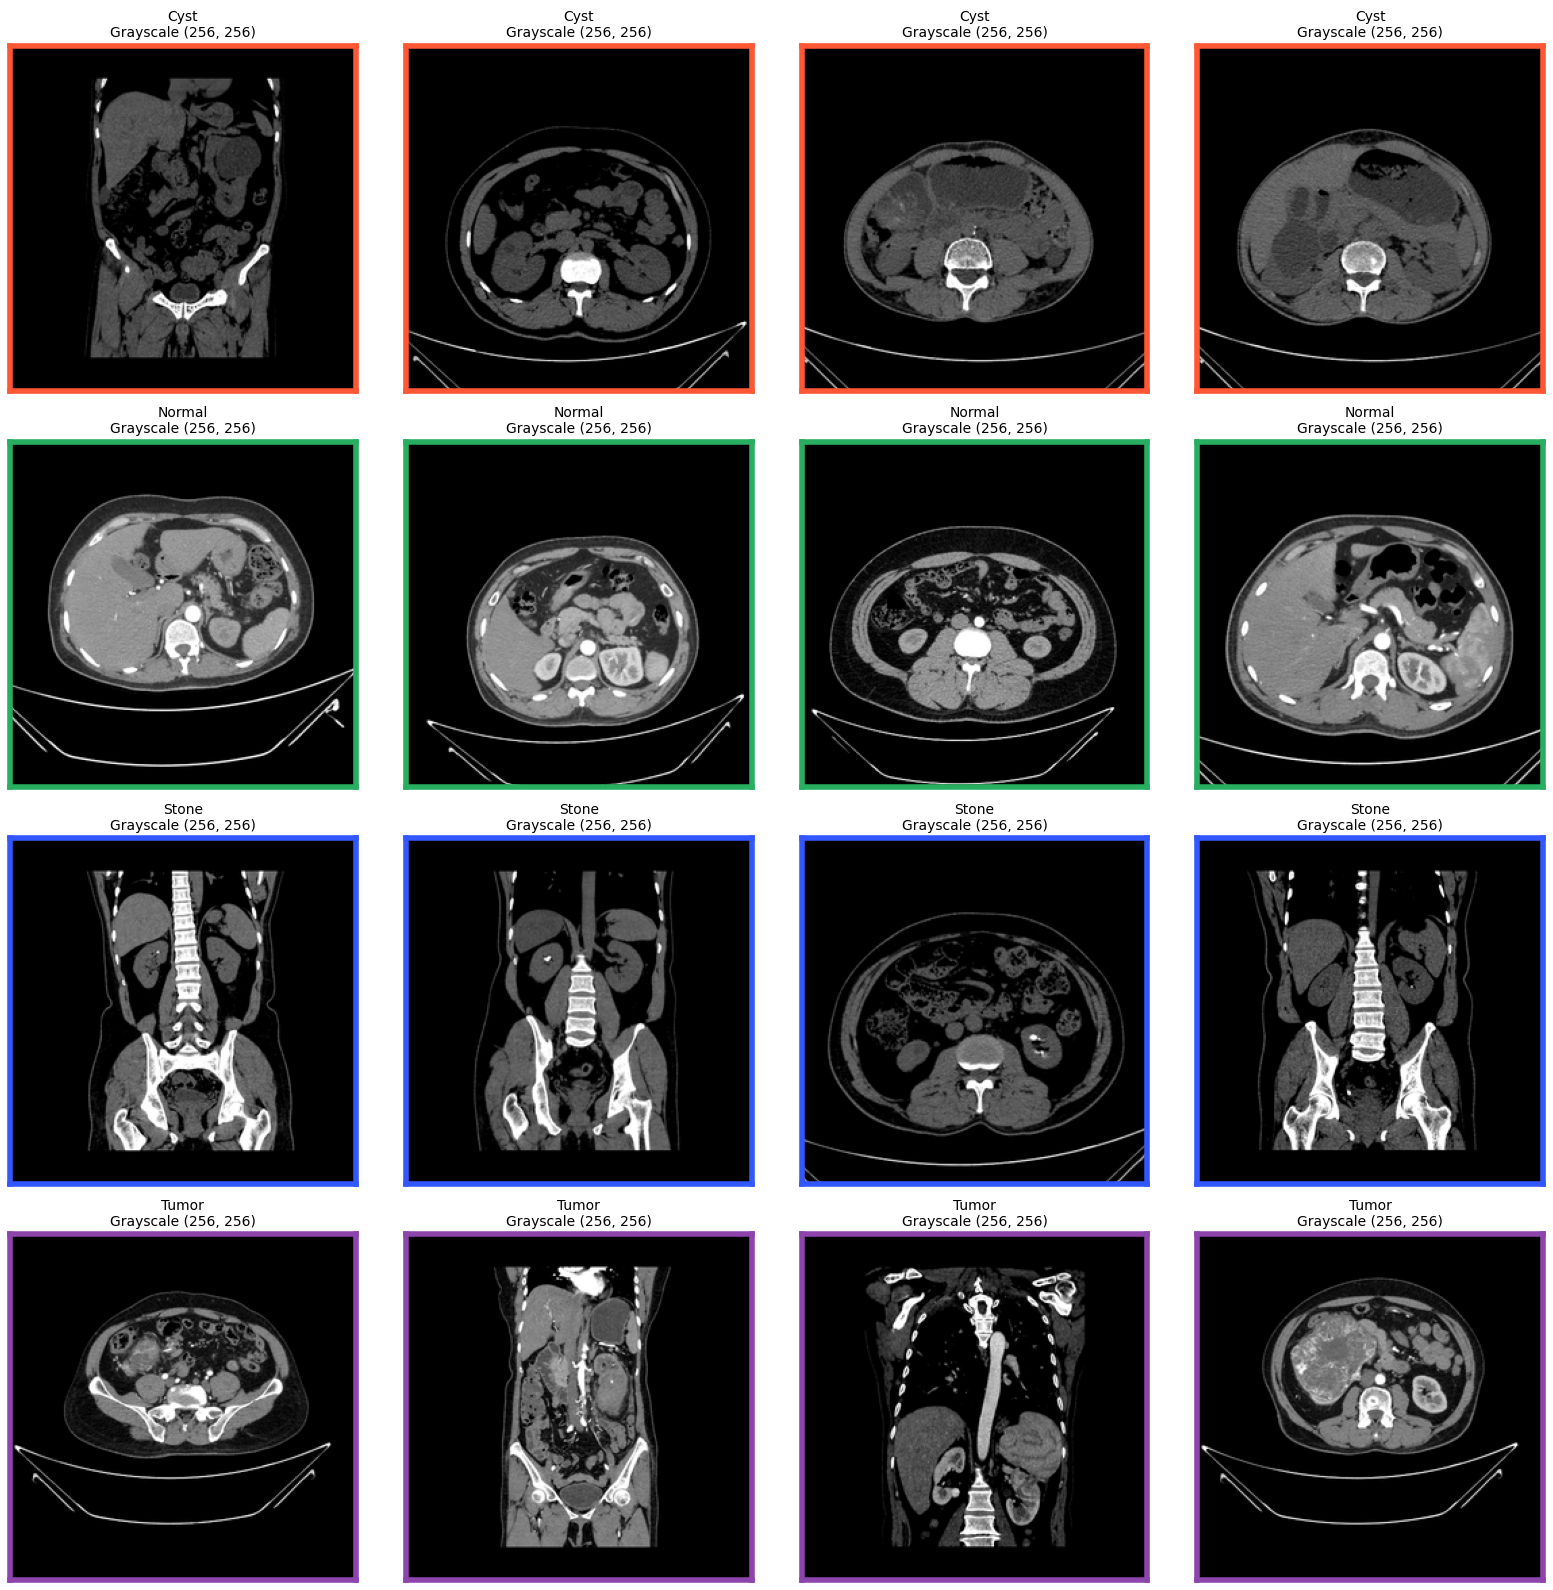

In [5]:
# 4 classes x 4 random samples from the training set
num_samples = 4

fig, axes = plt.subplots(num_classes, num_samples, figsize=(16, 4 * num_classes))

# Define a distinct color for each class
border_colors = ['#FF5733', '#27AE60', '#3357FF', '#8E44AD']

for i, class_name in enumerate(class_names):
    class_dir = train_dir / class_name
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    selected_images = random.sample(images, min(num_samples, len(images)))
    color = border_colors[i % len(border_colors)]

    for j, img_name in enumerate(selected_images):
        # Read with original channels to check color vs grayscale
        img = cv2.imread(str(class_dir / img_name), cv2.IMREAD_UNCHANGED)
        shape = img.shape
        color_type = 'Grayscale' if len(shape) == 2 else 'Color'

        ax = axes[i, j]
        ax.imshow(img if len(shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')
        ax.set_title(f"{class_name}\n{color_type} {shape}", fontsize=10)

        # Remove ticks but keep a colored border per class
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'sample_images.png', dpi=90, bbox_inches='tight')
plt.show()

# Image Statistics and EDA

### Item Count

In [6]:
counts_data = []

for split_name, split_dir in zip(['Train', 'Test', 'Validation'], [train_dir, test_dir, val_dir]):
    for class_name in class_names:
        class_dir = split_dir / class_name
        num_items = len([f for f in os.listdir(class_dir) if (class_dir / f).is_file()]) if class_dir.exists() else 0
        counts_data.append({'Split': split_name, 'Class': class_name, 'Count': num_items})

df_counts = pd.DataFrame(counts_data)

# Pivot so Splits are columns and Classes are rows
df_pivot = df_counts.pivot(index='Class', columns='Split', values='Count').fillna(0).astype(int)
df_pivot = df_pivot[['Train', 'Validation', 'Test']]

# Add Total row and column
df_pivot['Total'] = df_pivot.sum(axis=1)
df_pivot.loc['Total'] = df_pivot.sum(axis=0)

print("Number of items in each folder:")
display(df_pivot)

Number of items in each folder:


Split,Train,Validation,Test,Total
Class,,,,
Cyst,2298,493,493,3284
Normal,3503,750,749,5002
Stone,952,204,204,1360
Tumor,1600,342,341,2283
Total,8353,1789,1787,11929


### Target Distribution

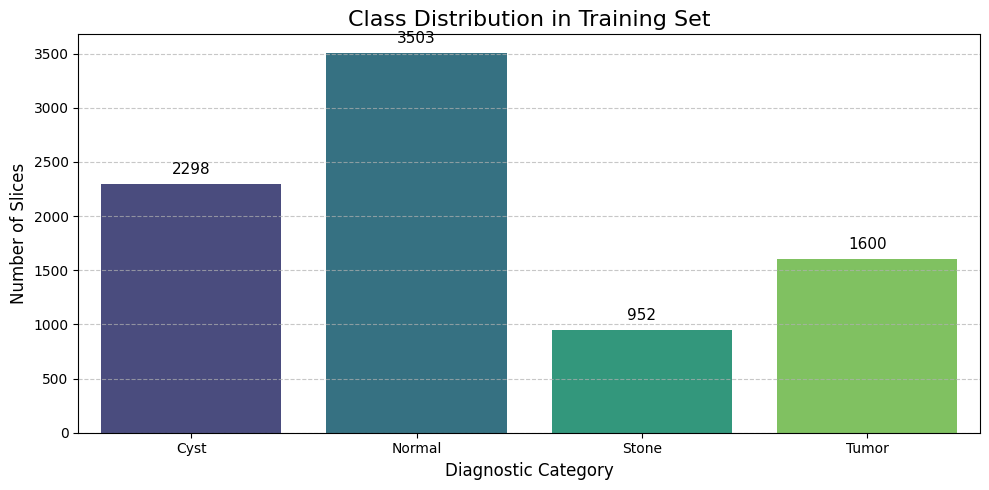

In [7]:
train_counts = df_counts[df_counts['Split'] == 'Train']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=train_counts, x='Class', y='Count', hue='Class', palette='viridis', legend=False)

plt.title('Class Distribution in Training Set', fontsize=16)
plt.xlabel('Diagnostic Category', fontsize=12)
plt.ylabel('Number of Slices', fontsize=12)

# Value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Resize

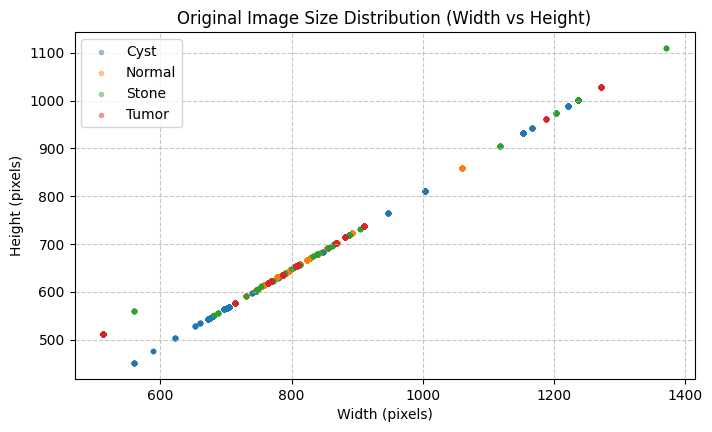


--- Sizing Analysis ---
Found 77 unique original image sizes; 61.5% are 512x512 axial slices.
➡️ CONCLUSION: Resizing IS REQUIRED. The non-square images are mostly coronal reformats, so each slice is padded to a square first (no anatomy is stretched) and then resized to 224x224.


In [8]:
# Original slice sizes (before the build script padded them to squares) come from the manifest
plt.figure(figsize=(8, 4.5))
for class_name in class_names:
    sub = manifest[manifest['label'] == class_name]
    plt.scatter(sub['orig_w'], sub['orig_h'], label=class_name, alpha=0.4, marker='.')

plt.title('Original Image Size Distribution (Width vs Height)')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

orig_sizes = manifest[['orig_w', 'orig_h']].apply(tuple, axis=1)
square_512 = (orig_sizes == (512, 512)).mean()
print(f"\n--- Sizing Analysis ---")
print(f"Found {orig_sizes.nunique()} unique original image sizes; {square_512:.1%} are 512x512 axial slices.")
print("➡️ CONCLUSION: Resizing IS REQUIRED. The non-square images are mostly coronal reformats, so each slice is "
      "padded to a square first (no anatomy is stretched) and then resized to 224x224.")

### Prepare Before EDA

In [9]:
from tqdm.notebook import tqdm

sample_size = 400     # per class is plenty for mean images and histograms

mean_images = {}
pixel_intensities = {}

print("Processing images for EDA...")
for class_name in tqdm(class_names, desc="Classes"):
    class_dir = train_dir / class_name
    images = sorted(os.listdir(class_dir))
    sampled = random.sample(images, min(sample_size, len(images)))

    mean_img = np.zeros((256, 256), dtype=np.float32)
    pixels = []
    for img_name in sampled:
        img = cv2.imread(str(class_dir / img_name), cv2.IMREAD_GRAYSCALE)
        mean_img += img
        pixels.extend(img.flatten()[::16])   # subsample pixels for the histogram

    mean_images[class_name] = mean_img / len(sampled)
    pixel_intensities[class_name] = np.array(pixels)

print("\nEDA Data Collection Complete!")

Processing images for EDA...


Classes:   0%|          | 0/4 [00:00<?, ?it/s]


EDA Data Collection Complete!


### Mean Image & Pixel Intensity Histogram

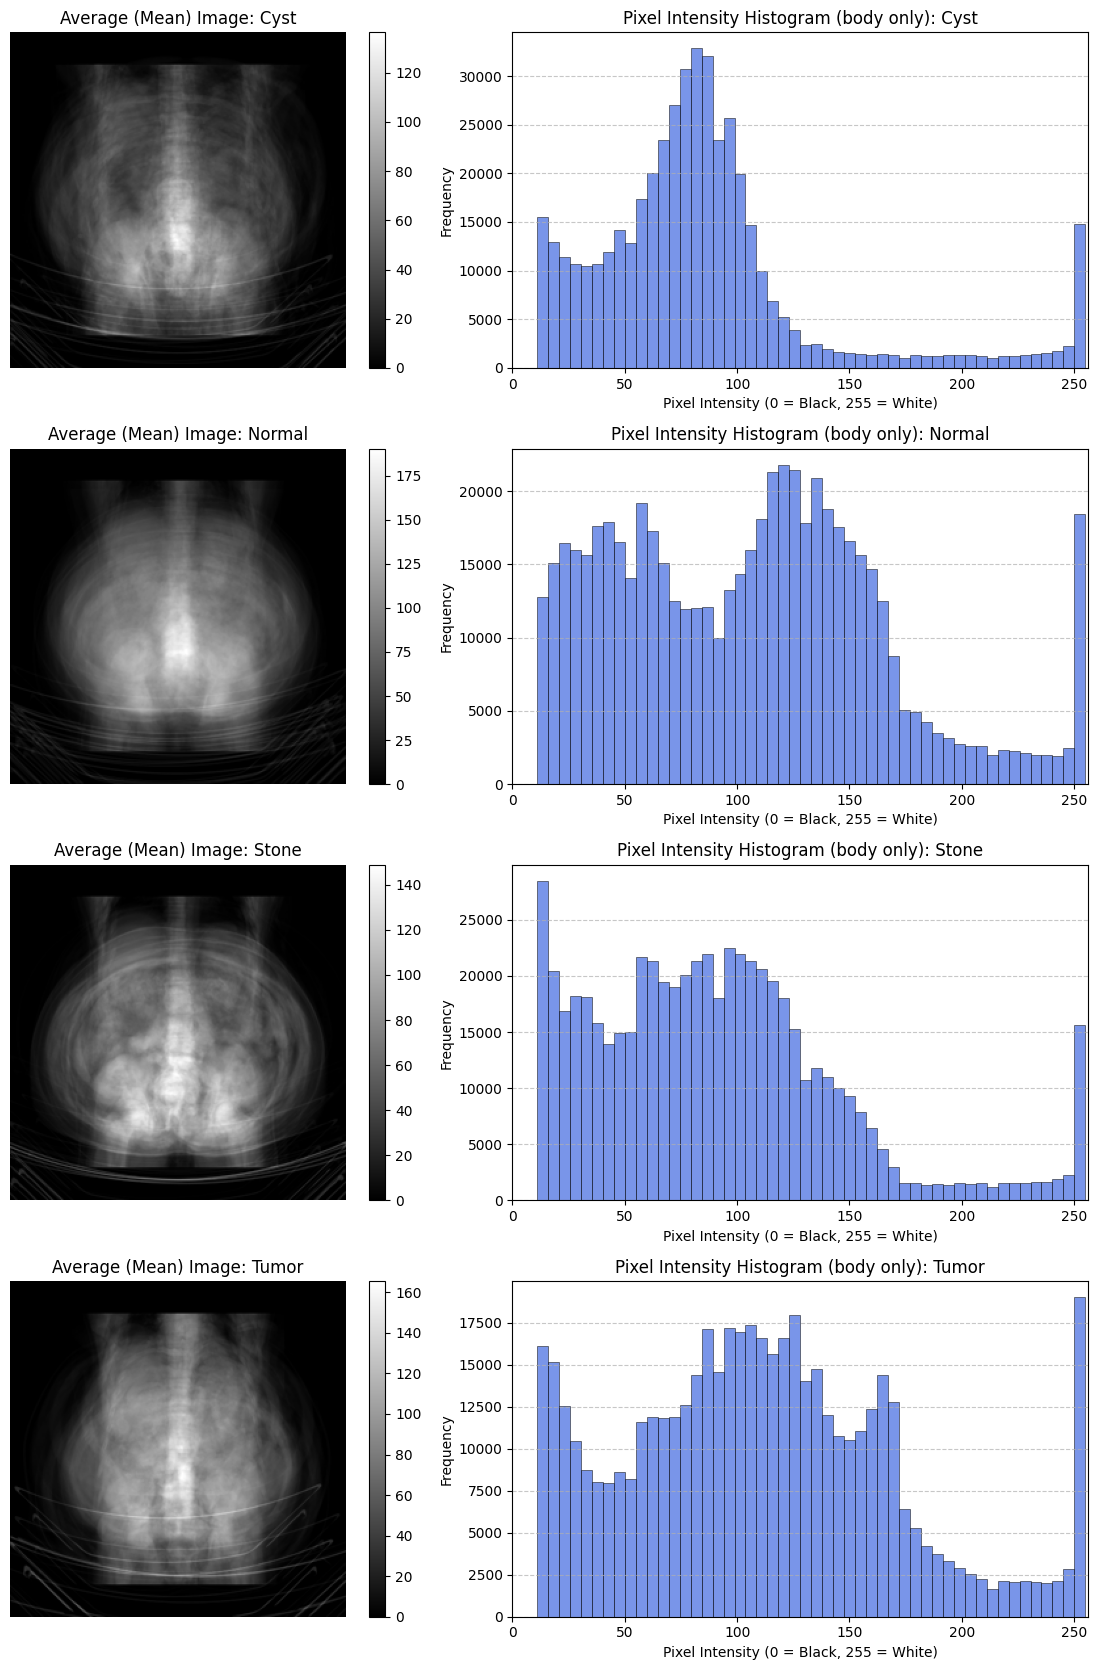

In [10]:
fig, axes = plt.subplots(num_classes, 2, figsize=(13, 4.2 * num_classes))

for i, class_name in enumerate(class_names):
    # A. Mean Image
    ax_img = axes[i, 0]
    im = ax_img.imshow(mean_images[class_name], cmap='gray')
    ax_img.set_title(f'Average (Mean) Image: {class_name}', fontsize=12)
    ax_img.axis('off')
    fig.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)

    # B. Pixel Intensity Histogram (black background pixels excluded - they dominate every slice)
    ax_hist = axes[i, 1]
    body = pixel_intensities[class_name][pixel_intensities[class_name] > 10]
    ax_hist.hist(body, bins=50, color='royalblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax_hist.set_title(f'Pixel Intensity Histogram (body only): {class_name}', fontsize=12)
    ax_hist.set_xlabel('Pixel Intensity (0 = Black, 255 = White)')
    ax_hist.set_ylabel('Frequency')
    ax_hist.set_xlim([0, 256])
    ax_hist.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'mean_image_pixel_histogram.png', dpi=90, bbox_inches='tight')
plt.show()

* **Mean Images (Visual Patterns):** All four averages show a blurred abdomen with the spine in the middle and the scanner table as a curved line at the bottom. Individual organs are not recognisable, because axial and coronal slices (57–66% of each class are 512×512 axial slices) are averaged together. No class has an obvious fixed marker such as text or a ruler that a model could latch onto.
* **Pixel Intensities (body only):** The classes differ clearly in brightness. **Cyst** body pixels peak around 80 (darker), **Normal** around 125, and **Tumor** spreads to 170. This largely reflects **acquisition**, not disease: contrast-enhanced scans make kidneys and vessels bright, and cyst and stone work-ups are often done without contrast or with a different display window. It is a potential **shortcut**, since a model can partly separate the classes by scan protocol. The limitations at the end come back to this.
* The spike at 255 in every class is bone (spine, ribs, pelvis) clipped at the top of the display window.

# Data Preprocessing

### Loading the Images
All 11,929 slices are held in memory as **single-channel** `uint8` arrays (~600 MB). They are expanded to 3 channels only one batch at a time, because the ImageNet backbones expect RGB. `load_image()` is the **only** preprocessing done outside the models: grayscale → pad to square → 224×224 → 3 channels, float 0–255. Each model scales the pixels itself (see Model Building), so a saved checkpoint needs nothing else at inference.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


def pad_to_square(img):
    """Pad with black (the CT background) so resizing never stretches anatomy."""
    w, h = img.size
    side = max(w, h)
    canvas = Image.new('L', (side, side), 0)
    canvas.paste(img, ((side - w) // 2, (side - h) // 2))
    return canvas


def load_gray(source, target_size=IMG_SIZE):
    """Path / PIL image -> uint8 array (H, W, 1)."""
    img = source if isinstance(source, Image.Image) else Image.open(source)
    img = pad_to_square(img.convert('L')).resize((target_size[1], target_size[0]), Image.BOX)
    return np.asarray(img, dtype=np.uint8)[..., None]


def load_image(source, target_size=IMG_SIZE):
    """Path / PIL image -> float32 array (H, W, 3) in 0-255, ready for any model below."""
    return np.repeat(load_gray(source, target_size), 3, axis=-1).astype(np.float32)


def load_split(split_dir):
    paths, labels = [], []
    for idx, class_name in enumerate(class_names):
        for f in sorted(os.listdir(split_dir / class_name)):
            paths.append(split_dir / class_name / f)
            labels.append(idx)
    X = np.stack([load_gray(p) for p in tqdm(paths, desc=split_dir.name, leave=False)])
    return X, np.array(labels), paths


print("Loading Training Data...")
X_train, y_train, train_paths = load_split(train_dir)
print(f"Found {len(X_train)} images belonging to {num_classes} classes.")

print("\nLoading Validation Data...")
X_val, y_val, val_paths = load_split(val_dir)
print(f"Found {len(X_val)} images belonging to {num_classes} classes.")

print("\nLoading Test Data...")
X_test, y_test, test_paths = load_split(test_dir)
print(f"Found {len(X_test)} images belonging to {num_classes} classes.")

Y_train = keras.utils.to_categorical(y_train, num_classes)
Y_val = keras.utils.to_categorical(y_val, num_classes)
Y_test = keras.utils.to_categorical(y_test, num_classes)

# Series id of every test / validation slice (for scan-level bootstrap intervals)
series_of = dict(zip(manifest['file'], manifest['series_id']))
test_series = np.array([series_of[p.relative_to(base_dir).as_posix()] for p in test_paths])
print(f"\nTrain array: {X_train.shape}, {X_train.nbytes / 1e6:.0f} MB")

Loading Training Data...


train:   0%|          | 0/8353 [00:00<?, ?it/s]

Found 8353 images belonging to 4 classes.

Loading Validation Data...


val:   0%|          | 0/1789 [00:00<?, ?it/s]

Found 1789 images belonging to 4 classes.

Loading Test Data...


test:   0%|          | 0/1787 [00:00<?, ?it/s]

Found 1787 images belonging to 4 classes.

Train array: (8353, 224, 224, 1), 419 MB


### Data Augmentation Setup
CT-appropriate but **strong** augmentation: rotation (±14°), zoom (±20%), shift (±10%), contrast (±30%) and brightness (±15%). These mimic patient positioning, field-of-view and window/level differences between scanners. Strong augmentation matters here: with only 123 training scans, the models otherwise memorise scan-specific details (see the training notes below).

The transforms run as one PyTorch `affine_grid` / `grid_sample` call on the GPU. Keras's `RandomRotation` / `RandomZoom` / `RandomTranslation` layers do the same job but take ~96 ms per batch on the PyTorch backend, against ~1 ms here.

**No flipping:** a left–right flip swaps liver and spleen and produces anatomy that does not occur (outside rare *situs inversus*). A vertical flip would put the spine in front of the abdomen.

In [12]:
AUG_ROTATION = 0.04     # fraction of a full turn (±14°)
AUG_ZOOM = 0.2          # ±20%
AUG_SHIFT = 0.1         # ±10% of the image size
AUG_CONTRAST = 0.3      # ±30%
AUG_BRIGHTNESS = 0.15   # ±15% of the 0-255 range


def augment_batch(xb):
    """(B, H, W, 3) float 0-255 -> randomly rotated / zoomed / shifted / contrast- and brightness-jittered copy."""
    x = torch.as_tensor(xb, device='cuda' if torch.cuda.is_available() else 'cpu').permute(0, 3, 1, 2)
    b = x.shape[0]
    u = lambda: torch.rand(b, device=x.device) * 2 - 1   # uniform in [-1, 1]
    angle = u() * AUG_ROTATION * 2 * np.pi
    scale = 1 + u() * AUG_ZOOM
    tx, ty = u() * AUG_SHIFT * 2, u() * AUG_SHIFT * 2   # affine_grid coordinates span [-1, 1]
    theta = torch.stack([torch.stack([torch.cos(angle) / scale, -torch.sin(angle) / scale, tx], 1),
                         torch.stack([torch.sin(angle) / scale, torch.cos(angle) / scale, ty], 1)], 1)
    grid = torch.nn.functional.affine_grid(theta, list(x.shape), align_corners=False)
    x = torch.nn.functional.grid_sample(x, grid, padding_mode='zeros', align_corners=False)   # black fill = CT background
    mean = x.mean(dim=(1, 2, 3), keepdim=True)
    x = (x - mean) * (1 + u()[:, None, None, None] * AUG_CONTRAST) + mean + u()[:, None, None, None] * AUG_BRIGHTNESS * 255
    return x.clamp(0, 255).permute(0, 2, 3, 1).cpu().numpy()


class CTSequence(keras.utils.PyDataset):
    """Batches from in-memory grayscale arrays -> 3-channel float 0-255, augmented on the fly (training only)."""

    def __init__(self, X, Y, batch_size=BATCH_SIZE, augment=False, shuffle=False, **kwargs):
        super().__init__(**kwargs)
        self.X, self.Y = X, Y
        self.batch_size, self.augment, self.shuffle = batch_size, augment, shuffle
        self.indices = np.arange(len(X))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        ids = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        xb = np.repeat(self.X[ids], 3, axis=-1).astype('float32')
        if self.augment:
            xb = augment_batch(xb)
        return xb, self.Y[ids]

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_generator = CTSequence(X_train, Y_train, augment=True, shuffle=True)
val_generator = CTSequence(X_val, Y_val)
test_generator = CTSequence(X_test, Y_test)
print(f"Training batches per epoch: {len(train_generator)}")

Training batches per epoch: 523


### Class Indices Mapping

In [13]:
# Mapping of class names to their numerical indices
class_indices = {name: i for i, name in enumerate(class_names)}
print("Class Indices Mapping:")
print(class_indices)

Class Indices Mapping:
{'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}


### Augmented Sample Preview
Verify that the augmentation produces realistic CT slices and never pushes a kidney out of the frame.

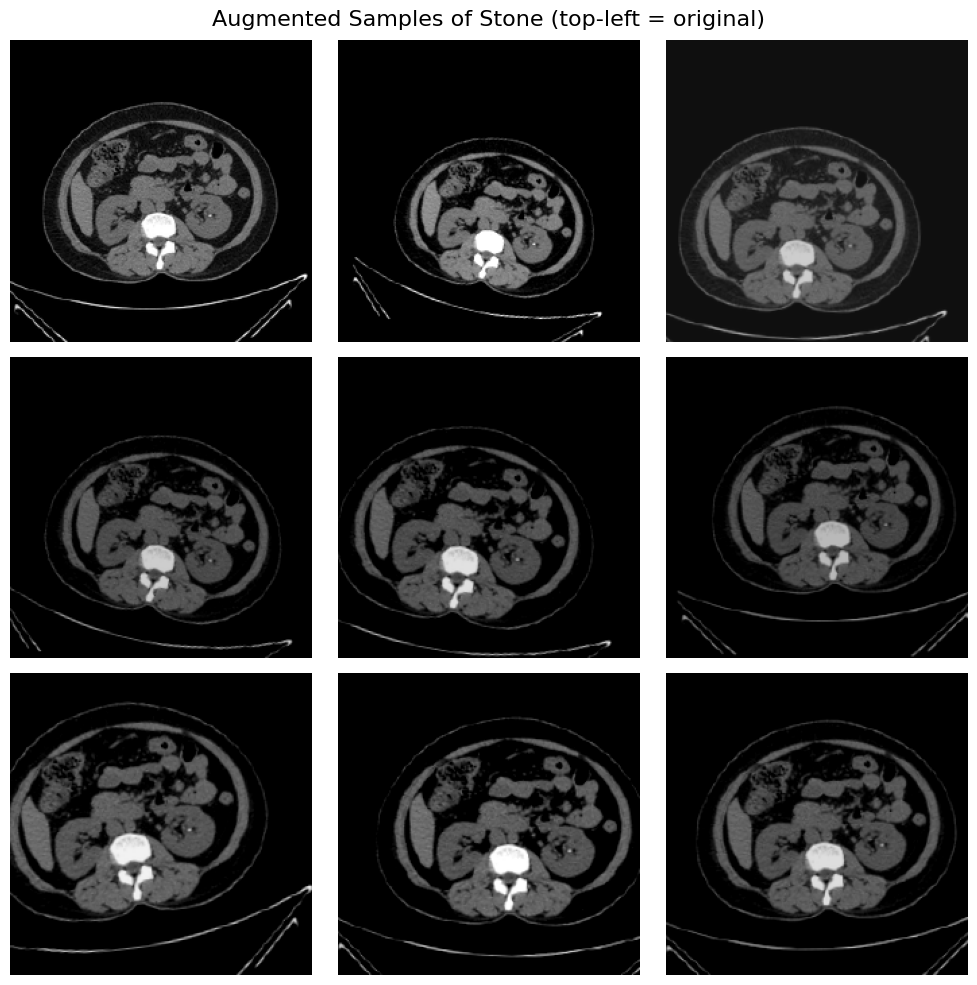

In [14]:
sample_class = 'Stone'
sample_idx = np.where(y_train == class_indices[sample_class])[0][0]
img_array = np.repeat(np.repeat(X_train[sample_idx:sample_idx + 1], 3, axis=-1).astype('float32'), 9, axis=0)
aug_imgs = augment_batch(img_array)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle(f'Augmented Samples of {sample_class} (top-left = original)', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow((img_array[0] if i == 0 else aug_imgs[i]).astype('uint8'))
    ax.axis('off')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'augmented_samples.png', dpi=90, bbox_inches='tight')
plt.show()

The transformations produce slices that look like the same scan acquired with the patient positioned slightly differently, zoomed to a different field of view, or displayed with a different window. The kidneys stay inside the frame, and the black padding matches the CT background, so the augmentation adds no artificial borders.

### Class Imbalance Handling (Class Weights)
Normal has 3.7× as many training slices as Stone. Balanced class weights make a mistake on a rare class cost proportionally more.

In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights mapped to indices:")
for class_idx, weight in class_weight_dict.items():
    print(f"{class_names[class_idx]:8s} (Index {class_idx}): {weight:.4f}")

Class Weights mapped to indices:
Cyst     (Index 0): 0.9087
Normal   (Index 1): 0.5961
Stone    (Index 2): 2.1935
Tumor    (Index 3): 1.3052


* **Stone (2.19)** is the most up-weighted class: it has the fewest training slices (952), even though it has the most scans (38). Stone scans are short series of about 25 slices.
* **Tumor (1.31)** is also up-weighted, while **Normal (0.60)**, the largest class, is down-weighted.
* Class weights balance *slices*, not *scans*: Tumor has only 15 training scans, so its effective diversity is still the lowest of all classes.

# Model Building

The lung module compared a Custom CNN, ResNet50, EfficientNetB0 and DenseNet121. Two changes here:

* **ConvNeXtTiny is added.** It is a modern CNN (2022) that borrows Vision Transformer design choices: large 7×7 kernels, LayerNorm, fewer activations. It is consistently stronger than ResNet/DenseNet at a similar cost, and it is the "ResNeXt/ConvNeXt" upgrade the lung notebook mentioned but did not try. Its LayerNorm (instead of BatchNorm) also makes it easy to fine-tune completely with small batches.
* **EfficientNetV2B0 replaces EfficientNetB0.** V2 trains faster and more stably at the same size.

**Input scaling.** Every model receives **raw 0–255 pixels** and applies its own preprocessing as its first layers. The lung notebook divided everything by 255, which broke EfficientNet (it rescales internally):

| Model | In-model preprocessing |
|---|---|
| Custom CNN | `Rescaling(1/255)` |
| ResNet50V2 | `Rescaling(1/127.5, offset=-1)` → [-1, 1] |
| EfficientNetV2B0 | none (built in) |
| DenseNet121 | `Rescaling(1/255)` + ImageNet mean/std `Normalization` |
| ConvNeXtTiny | none (built in) |

ResNet50**V2** replaces ResNet50 because V2's [-1, 1] scaling can be done with a standard layer, while ResNet50's RGB→BGR channel swap would need a `Lambda` layer, and a `.keras` file with a `Lambda` cannot be loaded in safe mode.

### Custom CNN Baseline

In [16]:
INPUT_SHAPE = IMG_SIZE + (3,)

# Four conv blocks + global average pooling. A Flatten head (as in the lung notebook)
# would put ~22M weights in a single dense layer.
custom_cnn = keras.Sequential([
    keras.Input(shape=INPUT_SHAPE),
    layers.Rescaling(1. / 255),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(name='gap'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
], name='Custom_CNN')

print("Custom CNN Baseline Summary:")
custom_cnn.summary()

Custom CNN Baseline Summary:


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

### Transfer-Learning Builder
All pre-trained models share the lung module's head: `GlobalAveragePooling2D → Dense(256) → Dropout(0.4) → Dense(4, softmax)`. The backbone is called with `training=False`, so its BatchNorm layers keep their ImageNet statistics even after unfreezing.

In [17]:
def build_transfer_model(name, backbone_fn, preprocessing):
    backbone = backbone_fn(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    backbone.trainable = False   # Phase 1: train only the new head

    inputs = keras.Input(shape=INPUT_SHAPE, name='ct_image')
    x = inputs
    for layer in preprocessing:
        x = layer(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name=name), backbone


def get_backbone(model):
    """The nested pre-trained model inside a transfer model (None for the Custom CNN)."""
    return next((l for l in model.layers if isinstance(l, keras.Model)), None)

### ResNet50V2

In [18]:
resnet_model, resnet_base = build_transfer_model(
    'ResNet50V2', keras.applications.ResNet50V2,
    [layers.Rescaling(1. / 127.5, offset=-1)])

print("ResNet50V2 Summary:")
resnet_model.summary()

ResNet50V2 Summary:


Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,090,372 (91.90 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

### EfficientNetV2B0

In [19]:
# EfficientNetV2B0 contains its own preprocessing and expects 0-255 input
effnet_model, effnet_base = build_transfer_model(
    'EfficientNetV2B0', keras.applications.EfficientNetV2B0, [])

print("EfficientNetV2B0 Summary:")
effnet_model.summary()

EfficientNetV2B0 Summary:


Model: "EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,276 (23.84 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

### DenseNet121

In [20]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

densenet_model, densenet_base = build_transfer_model(
    'DenseNet121', keras.applications.DenseNet121,
    [layers.Rescaling(1. / 255),
     layers.Normalization(mean=IMAGENET_MEAN, variance=[s ** 2 for s in IMAGENET_STD])])

print("DenseNet121 Summary:")
densenet_model.summary()

DenseNet121 Summary:


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

### ConvNeXtTiny

In [21]:
# ConvNeXtTiny contains its own normalization and expects 0-255 input
convnext_model, convnext_base = build_transfer_model(
    'ConvNeXtTiny', keras.applications.ConvNeXtTiny, [])

print("ConvNeXtTiny Summary:")
convnext_model.summary()

ConvNeXtTiny Summary:


Model: "ConvNeXtTiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,018,020 (106.88 MB)

 Trainable params: 197,892 (773.02 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

# Model Training

### Callbacks Setup

In [22]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Each model gets its own checkpoint file in ../models
def get_callbacks(model_name, patience=5):
    checkpoint_path = MODELS_DIR / f'{model_name}_best.keras'
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,   # stop if no improvement for `patience` epochs
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            verbose=1
        ),
        ModelCheckpoint(
            str(checkpoint_path),
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]

* **EarlyStopping** stops training once validation loss has not improved for 5 epochs (4 during fine-tuning) and restores the best weights.
* **ReduceLROnPlateau** shrinks the learning rate when validation loss stops improving.
* **ModelCheckpoint** keeps the best epoch on disk. It monitors `val_loss`: the validation set holds 30 unseen scans, and loss reacts to confident mistakes that accuracy hides.

### Train All Models (Phase 1: Initial Training)
The backbones are frozen and only the new heads learn, at learning rate 1e-3. For the pre-trained models this is a **short warm-up (5 epochs)**, so that Phase 2 does not start from a random head whose large gradients would disturb the pre-trained weights. The Custom CNN learns all its weights here, for up to 20 epochs.

**Resumable:** a model whose checkpoint already exists is loaded instead of retrained, so a crash or reboot costs one model, not the whole run. Start Jupyter with the environment variable `RETRAIN=1` to train everything from scratch.

In [23]:
from keras.optimizers import Adam

# Set the RETRAIN=1 environment variable to retrain even when checkpoints exist
RETRAIN = os.environ.get('RETRAIN', '0') == '1'
INITIAL_EPOCHS = {'Custom_CNN': 20}   # the pre-trained models get a 5-epoch head warm-up
WARMUP_EPOCHS = 5
HISTORY_PATH = RESULTS_DIR / 'training_history.json'

models_dict = {
    'Custom_CNN': custom_cnn,
    'ResNet50V2': resnet_model,
    'EfficientNetV2B0': effnet_model,
    'DenseNet121': densenet_model,
    'ConvNeXtTiny': convnext_model
}

# Training history is kept on disk so the plots survive a kernel restart
history_dict = json.loads(HISTORY_PATH.read_text()) if HISTORY_PATH.exists() and not RETRAIN else {}

for name, model in models_dict.items():
    ckpt = MODELS_DIR / f'{name}_best.keras'
    if ckpt.exists() and not RETRAIN:
        model.load_weights(ckpt)
        print(f"⏭️  {name}: checkpoint found, weights loaded (Phase 1 skipped)")
        continue

    print(f"\n{'=' * 50}\nTraining {name} - Phase 1\n{'=' * 50}")
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=INITIAL_EPOCHS.get(name, WARMUP_EPOCHS),
        class_weight=class_weight_dict,
        callbacks=get_callbacks(name),
        verbose=2
    )
    history_dict[f'{name}_phase1'] = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    HISTORY_PATH.write_text(json.dumps(history_dict))
    print(f"{name} Phase 1 finished in {time.time() - start:.0f}s")
    gc.collect()
    torch.cuda.empty_cache()   # free GPU memory before the next model


Training Custom_CNN - Phase 1
Epoch 1/20


523/523 - 37s - 70ms/step - accuracy: 0.4778 - loss: 1.2130 - val_accuracy: 0.2733 - val_loss: 1.5184 - learning_rate: 0.0010


Epoch 2/20


523/523 - 29s - 55ms/step - accuracy: 0.6054 - loss: 0.9577 - val_accuracy: 0.4584 - val_loss: 1.5468 - learning_rate: 0.0010


Epoch 3/20


...

523/523 - 39s - 74ms/step - accuracy: 0.9169 - loss: 0.2346 - val_accuracy: 0.6244 - val_loss: 1.4189 - learning_rate: 0.0010


Epoch 5/5


523/523 - 30s - 58ms/step - accuracy: 0.9400 - loss: 0.1716 - val_accuracy: 0.5992 - val_loss: 1.5125 - learning_rate: 3.0000e-04


Restoring model weights from the end of the best epoch: 2.


ConvNeXtTiny Phase 1 finished in 178s


* **Custom CNN:** learned from scratch for 12 epochs (early stopping). Its best validation loss (0.34, **88.3%** validation accuracy) came at epoch 7, while training accuracy reached 99%.
* **Pre-trained heads (warm-up):** all four reached their best validation loss in **epoch 1 or 2**, at only **63–76%** validation accuracy, while training accuracy kept climbing to 92–94%. A new head on frozen ImageNet features quickly fits the training scans but does not generalise to new ones. This is the same failure seen in this notebook's first run with the lung recipe, and the reason Phase 2 fine-tunes the whole network.

### Fine-Tuning Phase (Phase 2): Full Fine-Tuning
**All** backbone layers are unfrozen (BatchNorm layers stay frozen) and trained with AdamW (learning rate 3e-5, weight decay 0.05) and label smoothing 0.1.

**Why not the lung module's recipe?** The first run of this notebook used the lung recipe: the head trained on frozen features, then the top 30 layers fine-tuned at 1e-5. Every pre-trained model reached its best validation loss in **epoch 1**, while training accuracy climbed to 96–99%. The best validation macro-F1 was 0.59, below the Custom CNN's 0.78. A head on frozen ImageNet features memorises the 123 training scans instead of learning what separates the findings. Separate experiments, **scored on the validation set only**, compared recipes:

| Recipe (6 epochs) | Val macro-F1 |
|---|---|
| Lung recipe (DenseNet121) | 0.59 |
| Frozen backbone, linear head, lr 1e-4, strong aug, label smoothing (DenseNet121) | 0.45 |
| **Full fine-tuning, AdamW 3e-5, strong aug, label smoothing (EfficientNetV2B0)** | **0.90** |
| **Full fine-tuning, same recipe (ConvNeXtTiny)** | **0.92** |

The CT features that separate a cyst from a tumor are not among ImageNet's features, so the whole network has to adapt. Weight decay, label smoothing and strong augmentation keep it from memorising the training scans.

In [24]:
FINE_TUNE_EPOCHS = 12

ft_models = {
    'ResNet50V2_FT': (resnet_model, resnet_base),
    'EfficientNetV2B0_FT': (effnet_model, effnet_base),
    'DenseNet121_FT': (densenet_model, densenet_base),
    'ConvNeXtTiny_FT': (convnext_model, convnext_base)
}

for name, (model, base) in ft_models.items():
    # Unfreeze the whole backbone, but keep BatchNormalization frozen
    base.trainable = True
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    print(f"{name.replace('_FT', '')}: full backbone unfrozen, {len(base.trainable_weights)} trainable weight tensors (BatchNorm kept frozen).")

    ckpt = MODELS_DIR / f'{name}_best.keras'
    if ckpt.exists() and not RETRAIN:
        print(f"⏭️  {name}: checkpoint found (Phase 2 skipped)")
        continue

    print(f"\n{'=' * 50}\nFine-Tuning {name} - Phase 2\n{'=' * 50}")
    # Re-compile: low learning rate, weight decay and label smoothing against memorising the training scans
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=0.05),
                  loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])

    start = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(name, patience=4),
        verbose=2
    )
    history_dict[f'{name.replace("_FT", "")}_phase2'] = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    HISTORY_PATH.write_text(json.dumps(history_dict))
    print(f"{name} Phase 2 finished in {time.time() - start:.0f}s")
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll training and fine-tuning complete!")

ResNet50V2: full backbone unfrozen, 74 trainable weight tensors (BatchNorm kept frozen).

Fine-Tuning ResNet50V2_FT - Phase 2


Epoch 1/12


523/523 - 64s - 122ms/step - accuracy: 0.9190 - loss: 0.5695 - val_accuracy: 0.7367 - val_loss: 0.8268 - learning_rate: 3.0000e-05


Epoch 2/12


523/523 - 63s - 121ms/step - accuracy: 0.9838 - loss: 0.4368 - val_accuracy: 0.7831 - val_loss: 0.7134 - learning_rate: 3.0000e-05


...

Epoch 12/12


523/523 - 74s - 141ms/step - accuracy: 1.0000 - loss: 0.3672 - val_accuracy: 0.8463 - val_loss: 0.6334 - learning_rate: 3.0000e-05


Restoring model weights from the end of the best epoch: 11.


ConvNeXtTiny_FT Phase 2 finished in 899s



All training and fine-tuning complete!


* **Full fine-tuning closes the gap.** Validation accuracy jumps from 63–76% to **85–91%** for all four backbones: DenseNet121 **0.911**, ResNet50V2 0.881, EfficientNetV2B0 0.858, ConvNeXtTiny 0.852.
* All four ran the full 12 epochs without early stopping. The best epochs were 8–12, and EfficientNetV2B0 was still improving at epoch 12.
* Training accuracy reaches 100%, so the models do fit the training scans completely. Weight decay, label smoothing and strong augmentation keep validation performance improving anyway.
* In the 6-epoch recipe experiment (without warm-up) ConvNeXtTiny scored best; here DenseNet121 does. With 30 validation scans the ranking *between* fine-tuned backbones is not stable. Full fine-tuning versus frozen features is the difference that matters.

# Load Saved Models
Loads every checkpoint from `../models`. This works right after training and after a kernel restart: run the setup and data-loading cells, then continue from here. Both the Phase 1 and the fine-tuned (`_FT`) checkpoints are compared below.

In [25]:
# Free the training copies first: nine models + training state do not fit on an 8 GB GPU together
for _name in ['custom_cnn', 'resnet_model', 'effnet_model', 'densenet_model', 'convnext_model',
              'resnet_base', 'effnet_base', 'densenet_base', 'convnext_base',
              'models_dict', 'ft_models', 'model', 'base', 'history']:
    globals().pop(_name, None)
gc.collect()
torch.cuda.empty_cache()

arch_names = ['Custom_CNN', 'ResNet50V2', 'EfficientNetV2B0', 'DenseNet121', 'ConvNeXtTiny']
saved_model_files = {}
for arch in arch_names:
    saved_model_files[arch] = f'{arch}_best.keras'
    if arch != 'Custom_CNN':
        saved_model_files[f'{arch}_FT'] = f'{arch}_FT_best.keras'

loaded_models = {}
print("Loading models from ../models ...")
for model_name, filename in saved_model_files.items():
    filepath = MODELS_DIR / filename
    if filepath.exists():
        loaded_models[model_name] = keras.models.load_model(filepath)
        print(f"Loaded {model_name} from {filename}")
    else:
        print(f"⚠️ Could not find {filepath}")

print(f"\n{len(loaded_models)} models loaded into `loaded_models`!")

Loading models from ../models ...
Loaded Custom_CNN from Custom_CNN_best.keras


Loaded ResNet50V2 from ResNet50V2_best.keras


Loaded ResNet50V2_FT from ResNet50V2_FT_best.keras


Loaded EfficientNetV2B0 from EfficientNetV2B0_best.keras


Loaded EfficientNetV2B0_FT from EfficientNetV2B0_FT_best.keras


Loaded DenseNet121 from DenseNet121_best.keras


Loaded DenseNet121_FT from DenseNet121_FT_best.keras


Loaded ConvNeXtTiny from ConvNeXtTiny_best.keras


Loaded ConvNeXtTiny_FT from ConvNeXtTiny_FT_best.keras

9 models loaded into `loaded_models`!


# Evaluation & Model Comparison

### Training History Plots

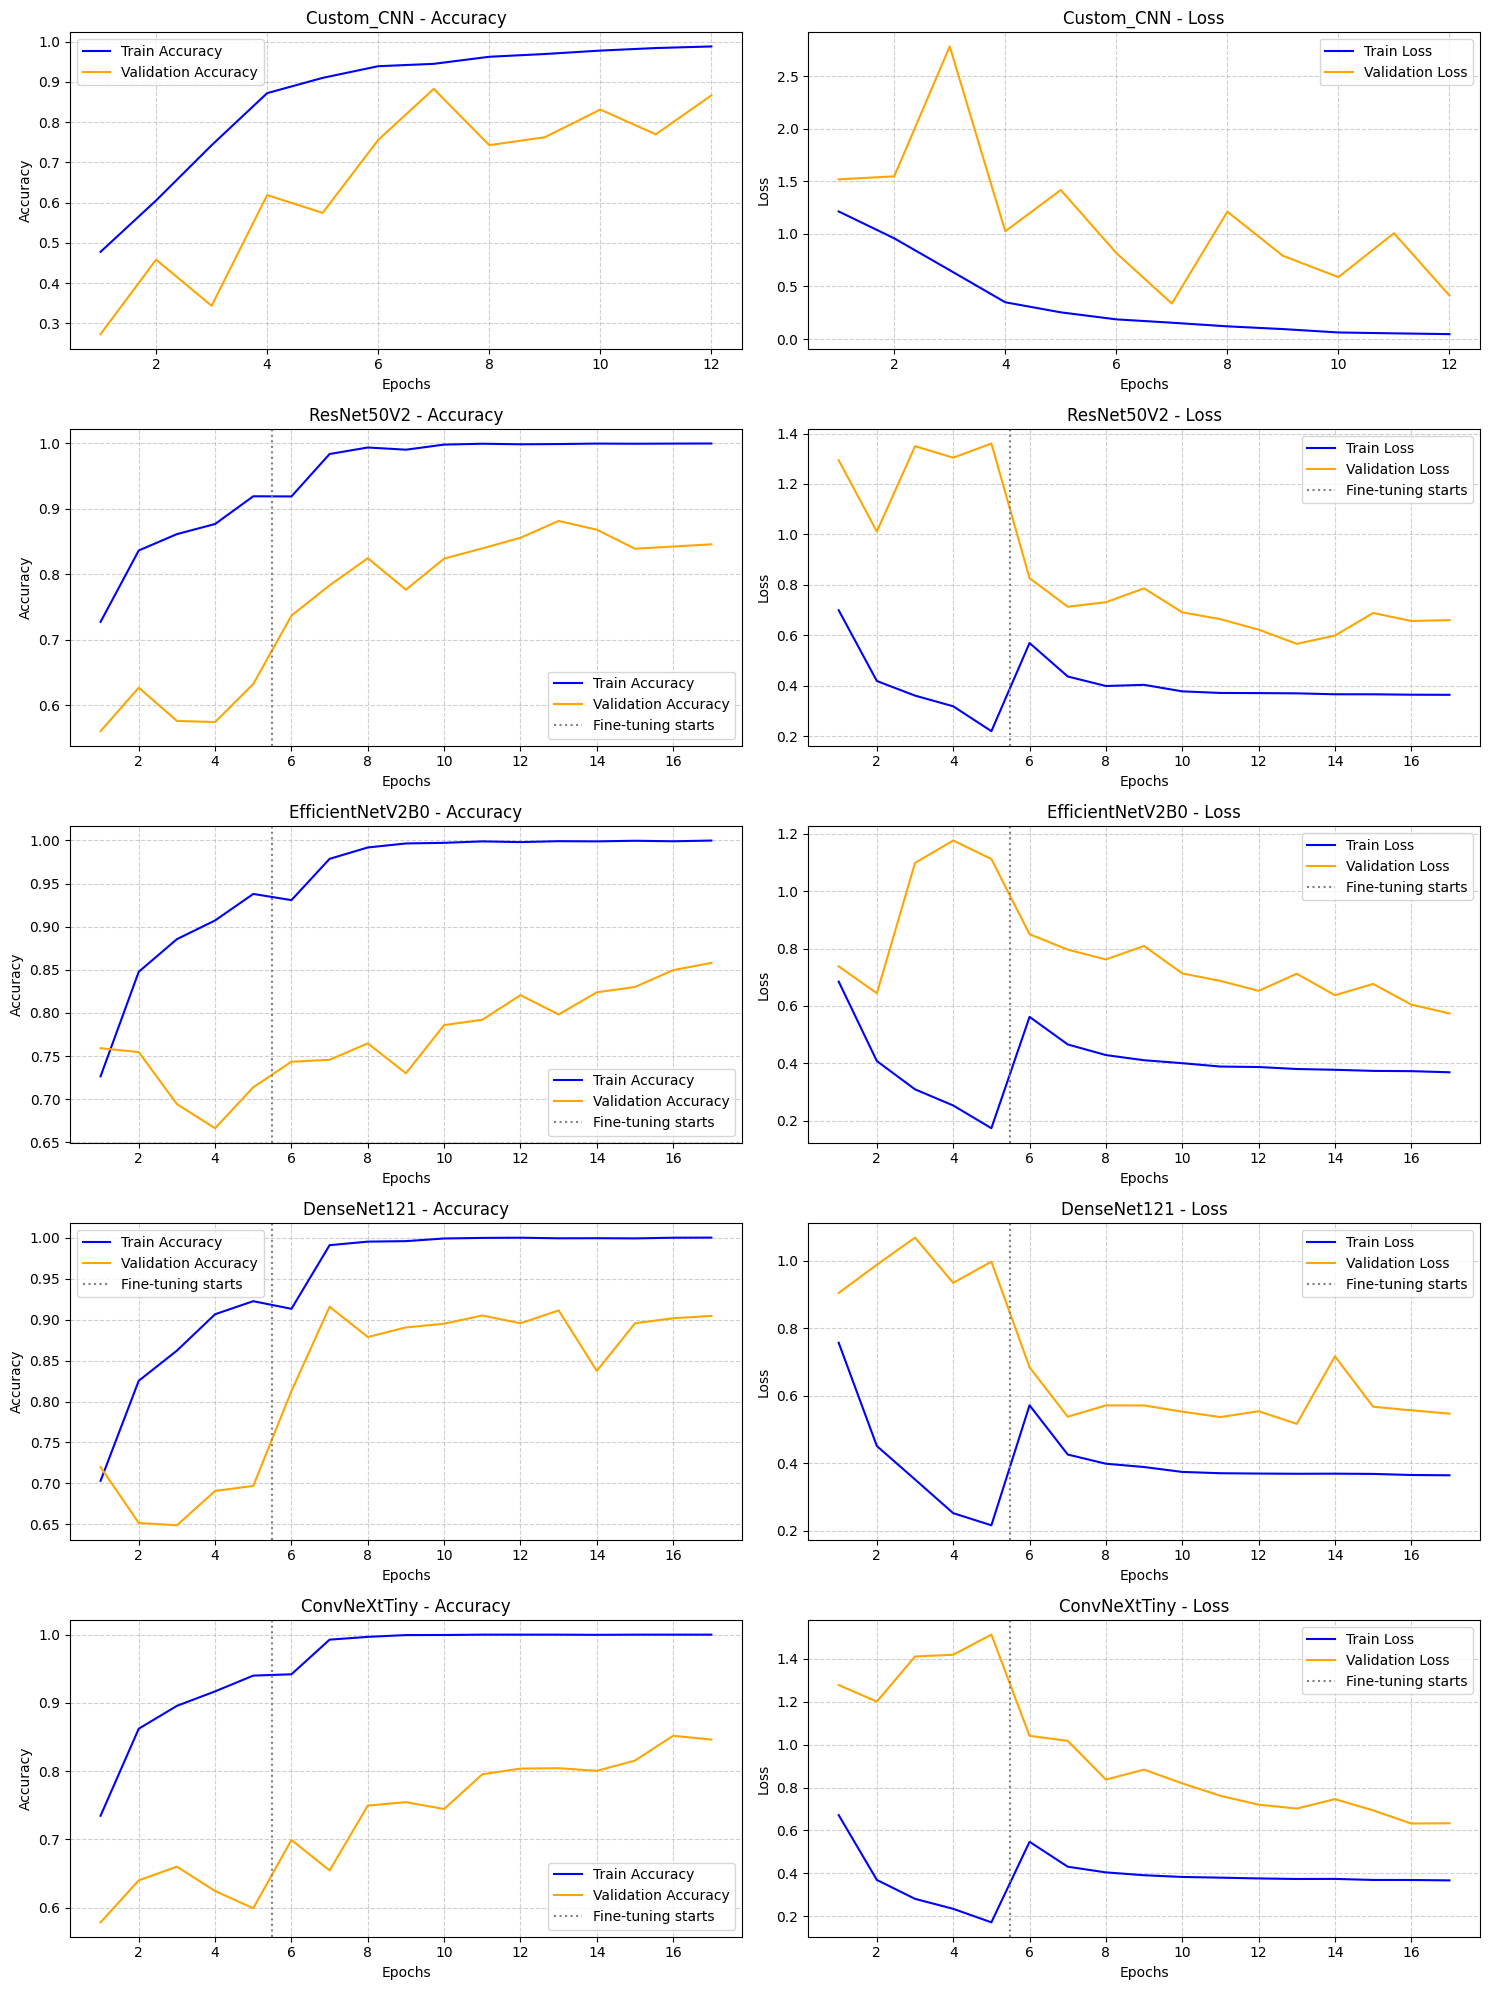

In [26]:
history_dict = json.loads(HISTORY_PATH.read_text()) if HISTORY_PATH.exists() else {}

if not history_dict:
    print("⚠️ No training history found. Skipping training history plots.")
else:
    fig, axes = plt.subplots(len(arch_names), 2, figsize=(15, 4 * len(arch_names)))

    for i, name in enumerate(arch_names):
        # Combine phase 1 and phase 2 histories
        h1 = history_dict.get(f'{name}_phase1', {})
        h2 = history_dict.get(f'{name}_phase2', {})
        n1 = len(h1.get('accuracy', []))

        for j, metric in enumerate(['accuracy', 'loss']):
            train_vals = h1.get(metric, []) + h2.get(metric, [])
            val_vals = h1.get(f'val_{metric}', []) + h2.get(f'val_{metric}', [])
            epochs = range(1, len(train_vals) + 1)
            ax = axes[i, j]
            ax.plot(epochs, train_vals, label=f'Train {metric.title()}', color='blue')
            ax.plot(epochs, val_vals, label=f'Validation {metric.title()}', color='orange')
            if h2:
                ax.axvline(n1 + 0.5, color='gray', linestyle=':', label='Fine-tuning starts')
            ax.set_title(f'{name} - {metric.title()}')
            ax.set_xlabel('Epochs')
            ax.set_ylabel(metric.title())
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'training_history.png', dpi=80, bbox_inches='tight')
    plt.show()

* **Phase 1 (left of the dotted line):** for every pre-trained model, training loss falls while validation loss *rises*, which is textbook overfitting of the frozen-feature head.
* **Phase 2:** after the dotted line, validation loss drops steadily for all four backbones and validation accuracy climbs to 0.85–0.91. The step up in *training* loss at the line is label smoothing: with smoothing 0.1 the lowest reachable loss is about 0.36, not 0.
* **Custom CNN:** validation loss swings a lot from epoch to epoch (1.0 → 2.8 → 1.0). A network trained from scratch on 123 scans is sensitive to which scans each batch happens to contain.

### Model Comparison Table
Every checkpoint is scored on both the validation and the test set. **The best model is chosen on validation macro-F1** (ties broken by validation loss), not on test accuracy as in the lung notebook: choosing on the test set and then reporting the test score overstates how well the chosen model generalises. Macro-F1 is used because accuracy is dominated by the large Normal class.

In [27]:
results = []
val_probs, test_probs = {}, {}

print("Evaluating models on the validation and test sets...")
for name, model in loaded_models.items():
    val_probs[name] = model.predict(val_generator, verbose=0)

    start_time = time.time()
    test_probs[name] = model.predict(test_generator, verbose=0)
    eval_time = time.time() - start_time

    vp, tp = val_probs[name], test_probs[name]
    results.append({
        'Model': name,
        'Val Accuracy': accuracy_score(y_val, vp.argmax(1)),
        'Val Macro F1': f1_score(y_val, vp.argmax(1), average='macro'),
        'Val Loss': log_loss(y_val, vp, labels=range(num_classes)),
        'Test Accuracy': accuracy_score(y_test, tp.argmax(1)),
        'Test Macro F1': f1_score(y_test, tp.argmax(1), average='macro'),
        'Test Macro ROC-AUC': roc_auc_score(y_test, tp, multi_class='ovr', average='macro'),
        'Test Loss': log_loss(y_test, tp, labels=range(num_classes)),
        'Total Parameters': model.count_params(),
        'Eval Time (s)': round(eval_time, 2)
    })

df_results = pd.DataFrame(results)
df_results.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)

styled_df = (df_results.style
             .format({c: '{:.4f}' for c in df_results.columns if 'Accuracy' in c or 'F1' in c or 'AUC' in c or 'Loss' in c})
             .format({'Total Parameters': '{:,}'})
             .highlight_max(subset=['Val Accuracy', 'Val Macro F1', 'Test Accuracy', 'Test Macro F1', 'Test Macro ROC-AUC'], color='lightgreen')
             .highlight_min(subset=['Val Loss', 'Test Loss'], color='lightgreen'))
display(styled_df)

# Select on validation: highest macro-F1, then lowest loss
ranked = df_results.sort_values(['Val Macro F1', 'Val Loss'], ascending=[False, True])
best_model_name = ranked.iloc[0]['Model']
best_model = loaded_models[best_model_name]
print(f"\n🏆 Best Model (validation macro-F1, then validation loss): {best_model_name}")

Evaluating models on the validation and test sets...


,Model,Val Accuracy,Val Macro F1,Val Loss,Test Accuracy,Test Macro F1,Test Macro ROC-AUC,Test Loss,Total Parameters,Eval Time (s)
0,Custom_CNN,0.883175,0.816065,0.336730,0.729715,0.696139,0.928420,0.851486,"423,748",3.340000
1,ResNet50V2,0.626607,0.530095,1.011528,0.585339,0.504814,0.839582,1.178098,"24,090,372",15.710000
2,ResNet50V2_FT,0.881498,0.844439,0.346783,0.867935,0.825949,0.973120,0.429140,"24,090,372",6.970000
3,EfficientNetV2B0,0.754053,0.703898,0.644263,0.562955,0.526763,0.854132,1.042187,"6,248,276",22.960000
4,EfficientNetV2B0_FT,0.858021,0.816704,0.367407,0.806379,0.737234,0.965384,0.508011,"6,248,276",8.680000
5,DenseNet121,0.719955,0.592668,0.904767,0.639060,0.520090,0.869100,0.915286,"7,300,932",33.350000
6,DenseNet121_FT,0.911124,0.889454,0.285323,0.894236,0.867016,0.975863,0.348022,"7,300,932",22.820000
7,ConvNeXtTiny,0.640022,0.545723,1.200484,0.601567,0.472275,0.762459,1.209619,"28,018,020",9.460000
8,ConvNeXtTiny_FT,0.851873,0.794203,0.453677,0.850588,0.797809,0.968498,0.484308,"28,018,020",4.600000



🏆 Best Model (validation macro-F1, then validation loss): DenseNet121_FT


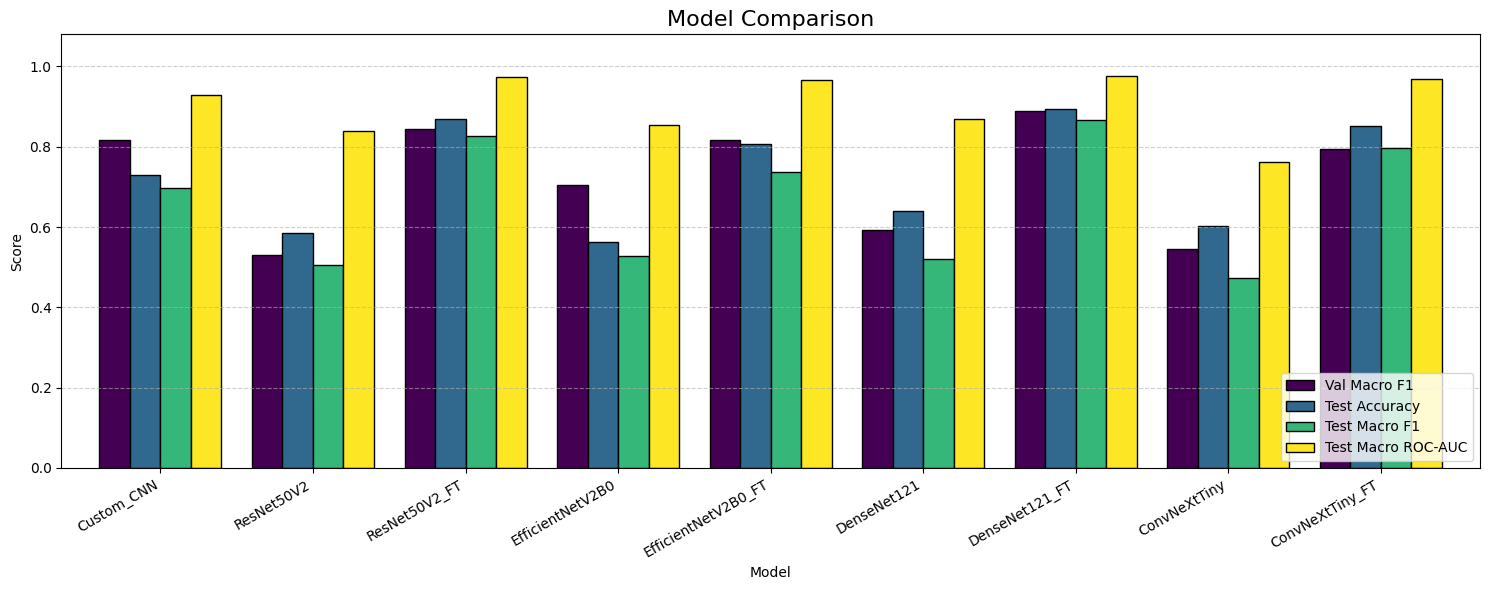

In [28]:
# Visual comparison
plot_df = df_results.set_index('Model')[['Val Macro F1', 'Test Accuracy', 'Test Macro F1', 'Test Macro ROC-AUC']]
ax = plot_df.plot(kind='bar', figsize=(15, 6), width=0.8, colormap='viridis', edgecolor='black')
ax.set_title('Model Comparison', fontsize=16)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

**Observation on Model Comparison:**
* **DenseNet121 (fully fine-tuned)** has the best validation macro-F1 (**0.889**, loss 0.29) and holds up on the unseen test scans: **89.4% accuracy, 0.867 macro-F1, 0.976 macro ROC-AUC**.
* **Fine-tuning is decisive:** every backbone gains 20–30 points of test accuracy from Phase 1 (0.56–0.64) to Phase 2 (0.81–0.89).
* **ResNet50V2_FT** (0.868 test accuracy) and **ConvNeXtTiny_FT** (0.851) are close behind. EfficientNetV2B0_FT is weakest among the fine-tuned models (0.806).
* **Custom CNN:** strong on validation (0.815 macro-F1) but only 0.730 test accuracy, the largest validation-to-test drop. With 30 validation and 36 test scans, a model can be lucky on one set of scans. This is why the scan-level confidence interval below matters.

### How Precise Is the Test Score?
The 1,787 test slices are **not** 1,787 independent observations: they come from 36 scans, and slices of one scan tend to be right or wrong together. The confidence interval therefore uses a **scan-level (cluster) bootstrap**: whole series are resampled, not individual slices.

In [29]:
rng = np.random.default_rng(SEED)
best_test_pred = test_probs[best_model_name].argmax(1)
unique_series = np.unique(test_series)
series_index = {s: np.where(test_series == s)[0] for s in unique_series}

boot_acc, boot_f1 = [], []
for _ in range(2000):
    idx = np.concatenate([series_index[s] for s in rng.choice(unique_series, len(unique_series), replace=True)])
    boot_acc.append(accuracy_score(y_test[idx], best_test_pred[idx]))
    boot_f1.append(f1_score(y_test[idx], best_test_pred[idx], average='macro', labels=range(num_classes), zero_division=0))

acc_ci = np.percentile(boot_acc, [2.5, 97.5])
f1_ci = np.percentile(boot_f1, [2.5, 97.5])
print(f"{best_model_name} on the test set ({len(unique_series)} scans, 95% scan-level bootstrap CI):")
print(f"  Accuracy : {accuracy_score(y_test, best_test_pred):.3f}  [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]")
print(f"  Macro F1 : {f1_score(y_test, best_test_pred, average='macro'):.3f}  [{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]")

# Per-scan view: share of slices classified correctly in each test series
per_series = pd.DataFrame({'series': test_series, 'label': [class_names[i] for i in y_test],
                           'correct': best_test_pred == y_test})
series_acc = per_series.groupby(['label', 'series'])['correct'].agg(['mean', 'size']).reset_index()
print("\nPer-scan slice accuracy (distribution across test scans):")
display(series_acc.groupby('label')['mean'].describe()[['count', 'min', '25%', '50%', 'mean']].round(3))

DenseNet121_FT on the test set (36 scans, 95% scan-level bootstrap CI):
  Accuracy : 0.894  [0.821, 0.959]
  Macro F1 : 0.867  [0.701, 0.912]

Per-scan slice accuracy (distribution across test scans):


,count,min,25%,50%,mean
label,,,,,
Cyst,12.0,0.837,1.000,1.000,0.986
Normal,8.0,0.916,0.976,1.000,0.980
Stone,12.0,0.000,0.489,0.827,0.684
Tumor,4.0,0.098,0.181,0.469,0.504


* The scan-level 95% interval is wide: **accuracy 0.82–0.96, macro-F1 0.70–0.91**. Resampling whole scans (not slices) shows how much the score depends on *which* 36 scans ended up in the test set.
* **Per scan**, the model is reliable for **Cyst** (every test scan ≥ 84% of slices correct) and **Normal** (every scan ≥ 92%).
* **Stone** is mixed: the median scan is 83% correct, but one stone scan has **0%** of its slices right.
* **Tumor** is the weak class: across only **4 test scans**, the mean per-scan accuracy is 50%, and one scan has only 10% of its slices right. Whole *patients* can be missed, not just scattered slices, and the tumor result rests on four patients.

### Confusion Matrix + Classification Report

Generating predictions using DenseNet121_FT...


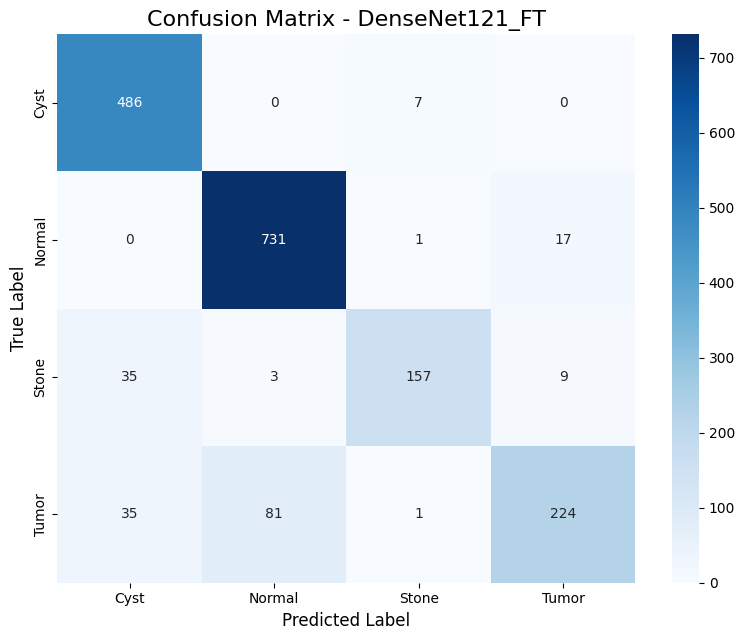


Classification Report:
              precision    recall  f1-score   support

        Cyst      0.874     0.986     0.927       493
      Normal      0.897     0.976     0.935       749
       Stone      0.946     0.770     0.849       204
       Tumor      0.896     0.657     0.758       341

    accuracy                          0.894      1787
   macro avg      0.903     0.847     0.867      1787
weighted avg      0.896     0.894     0.889      1787



In [30]:
print(f"Generating predictions using {best_model_name}...")
Y_pred = test_probs[best_model_name]
y_pred = Y_pred.argmax(axis=1)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
pd.DataFrame(report).T.to_csv(RESULTS_DIR / 'classification_report.csv')

* **Strongest:** **Cyst** (486 of 493, recall 0.99) and **Normal** (731 of 749, recall 0.98).
* **Weakest:** **Tumor**, with recall **0.66**: 81 tumor slices are called Normal and 35 are called Cyst. Most of these errors come from the one or two test tumor scans the model largely misses (see the per-scan table above). Tumor slices at the top or bottom of the kidney, where the mass is small or out of plane, look normal on a single slice.
* **Stone → Cyst (35 slices):** a stone is a few bright pixels, and at 224×224 it can shrink to 1–2 pixels. Without it, the slice is just a non-contrast kidney scan, like many cyst work-ups.
* **Precision is high for every class (0.87–0.95).** When the model names a finding, it is usually right; its main failure is *missing* tumors and stones.

### ROC-AUC Curves

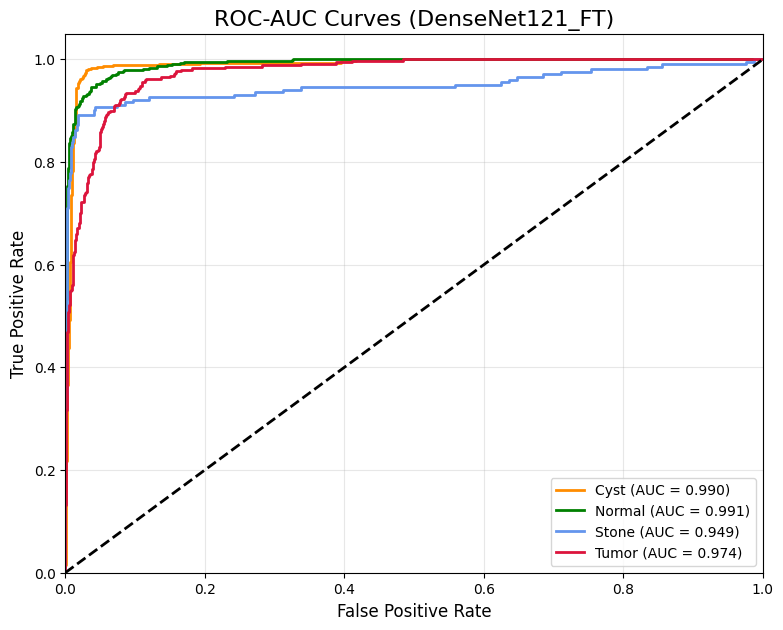

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for one-vs-rest ROC
y_test_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(9, 7))
colors = ['darkorange', 'green', 'cornflowerblue', 'crimson']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], Y_pred[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):0.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC-AUC Curves ({best_model_name})', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'roc_auc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

* AUCs are high for all classes: **Normal 0.991, Cyst 0.990, Tumor 0.974, Stone 0.949**.
* Tumor's high AUC next to its low recall means the model *ranks* tumor slices above the others fairly well but its default argmax decision is too conservative. A tumor-specific threshold (flagging any slice with, e.g., > 20% tumor probability) would recover many missed tumors, at the cost of more false alarms.
* Stone's curve plateaus near 90% true-positive rate: some stone slices get almost no stone probability at all. These are the missed stone scan(s).

### Misclassified Examples

Total misclassified images: 189 out of 1787


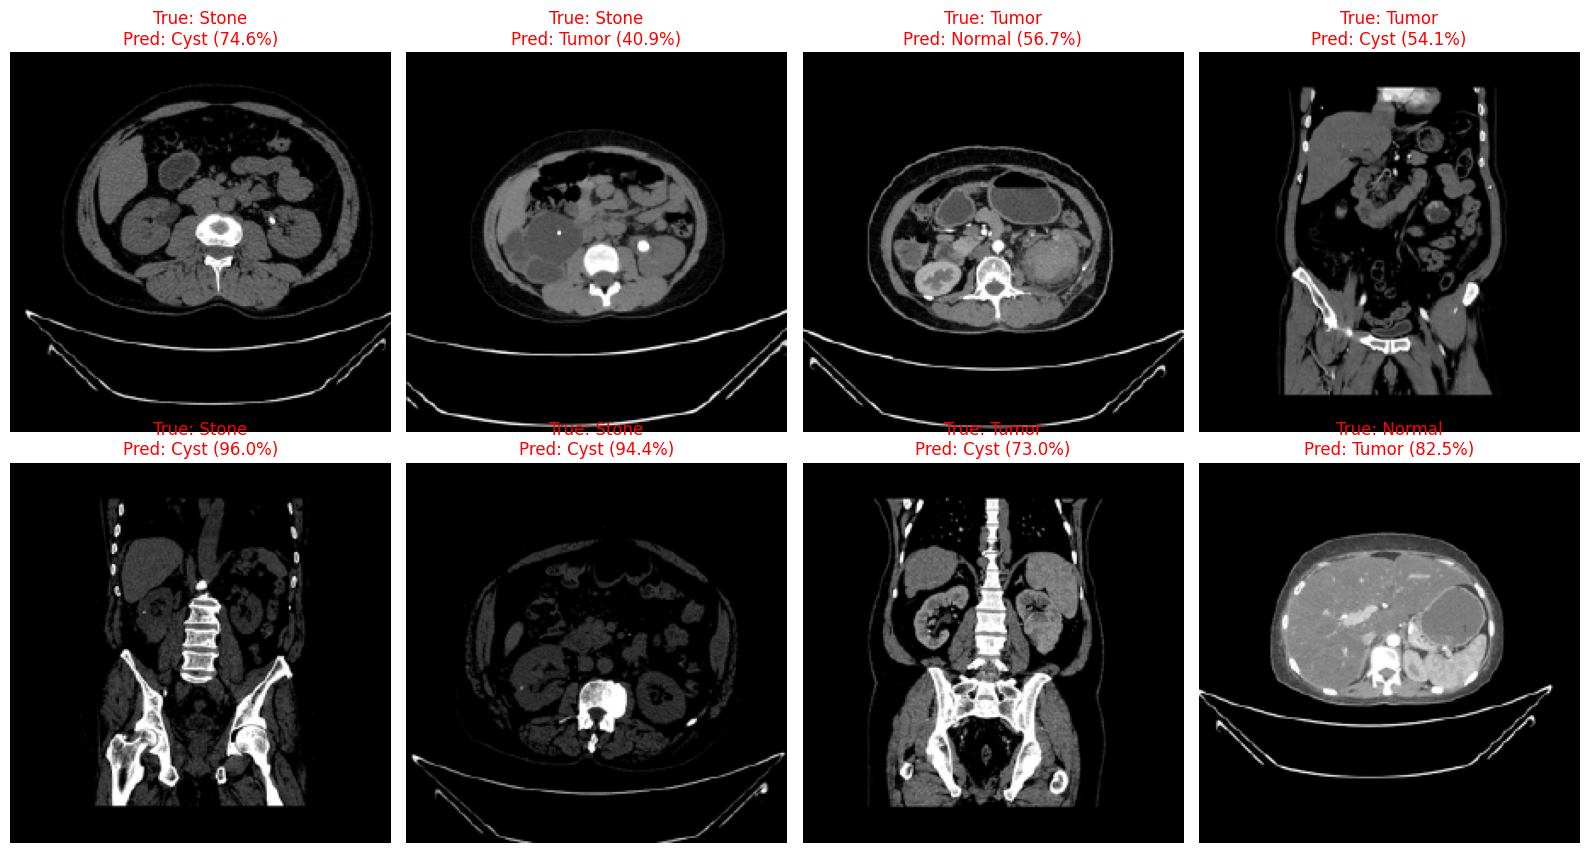

In [32]:
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_true)}")

num_to_show = min(8, len(misclassified_idx))
if num_to_show > 0:
    # Spread the examples over different scans instead of 8 neighbouring slices of one scan
    shown, used_series = [], set()
    for idx in rng.permutation(misclassified_idx):
        if test_series[idx] not in used_series:
            shown.append(idx)
            used_series.add(test_series[idx])
        if len(shown) == num_to_show:
            break

    fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
    axes = axes.flatten()
    for ax, idx in zip(axes, shown):
        ax.imshow(X_test[idx, ..., 0], cmap='gray')
        ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]} "
                     f"({Y_pred[idx].max() * 100:.1f}%)", color='red')
        ax.axis('off')
    for ax in axes[len(shown):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images found.")

189 of 1,787 test slices are misclassified. The eight examples above come from eight different scans:
* **Stone → Cyst / Tumor (4):** all on non-contrast slices. In two of them the stone is visible as a bright dot, but the slice *also* shows a large low-density mass in the kidney. The patient has more than one finding, and a single-label dataset cannot express that. The model's "Cyst" or "Tumor" answer is arguably not wrong about the image, only about the label.
* **Tumor → Normal / Cyst (3):** slices where the tumor is small or where a coronal slice cuts the kidney at the edge of the mass.
* **Normal → Tumor (1, 82.5%):** a contrast-enhanced upper-abdomen slice with a large fluid-filled structure next to the left kidney, which looks like a mass.
* **5 of the 8** have confidence below 75% and would be flagged for review. The other 3 (96.0%, 94.4%, 82.5%) are confident mistakes that the confidence check cannot catch.

# Explainability — Grad-CAM

### Explainability — Grad-CAM
Grad-CAM shows *where* the model looks. For a kidney finding the heat should sit on the **kidneys** (the paired organs either side of the spine), not on the scanner table, the body outline, the liver or the bowel.

With the PyTorch backend the gradients come from `torch.autograd` instead of `tf.GradientTape`. The model is run layer by layer, and the feature map of the last convolutional stage is detached and marked as requiring gradients, so the head's gradient with respect to it can be taken even when the backbone is frozen.

In [33]:
import matplotlib

def gradcam_target_layer(model):
    """Backbone output for transfer models, last Conv2D for the Custom CNN."""
    backbone = get_backbone(model)
    return backbone if backbone is not None else [l for l in model.layers if isinstance(l, layers.Conv2D)][-1]


def make_gradcam_heatmap(img_array, model, pred_index=None):
    """img_array: (1, H, W, 3) float32 in 0-255. Returns (heatmap in [0, 1], class probabilities)."""
    target = gradcam_target_layer(model)
    x = keras.ops.convert_to_tensor(img_array)
    conv_outputs = None

    with torch.enable_grad():
        for layer in model.layers:
            if isinstance(layer, layers.InputLayer):
                continue
            x = layer(x, training=False)
            if layer is target:
                # Cut the graph here so gradients stop at the feature map
                conv_outputs = x.detach().requires_grad_(True)
                x = conv_outputs
        preds = x
        if pred_index is None:
            pred_index = int(torch.argmax(preds[0]))
        class_channel = preds[:, pred_index]
        grads = torch.autograd.grad(class_channel.sum(), conv_outputs)[0]

    # Average gradients spatially, then weight each channel by its importance
    pooled_grads = grads.mean(dim=(0, 1, 2))
    heatmap = (conv_outputs[0] @ pooled_grads[..., None]).squeeze(-1)

    # Keep positive influence only and normalize to [0, 1]
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap.detach().cpu().numpy(), keras.ops.convert_to_numpy(preds[0])


print("Grad-CAM implementation ready.")

Grad-CAM implementation ready.


### Grad-CAM Heatmap Visualization

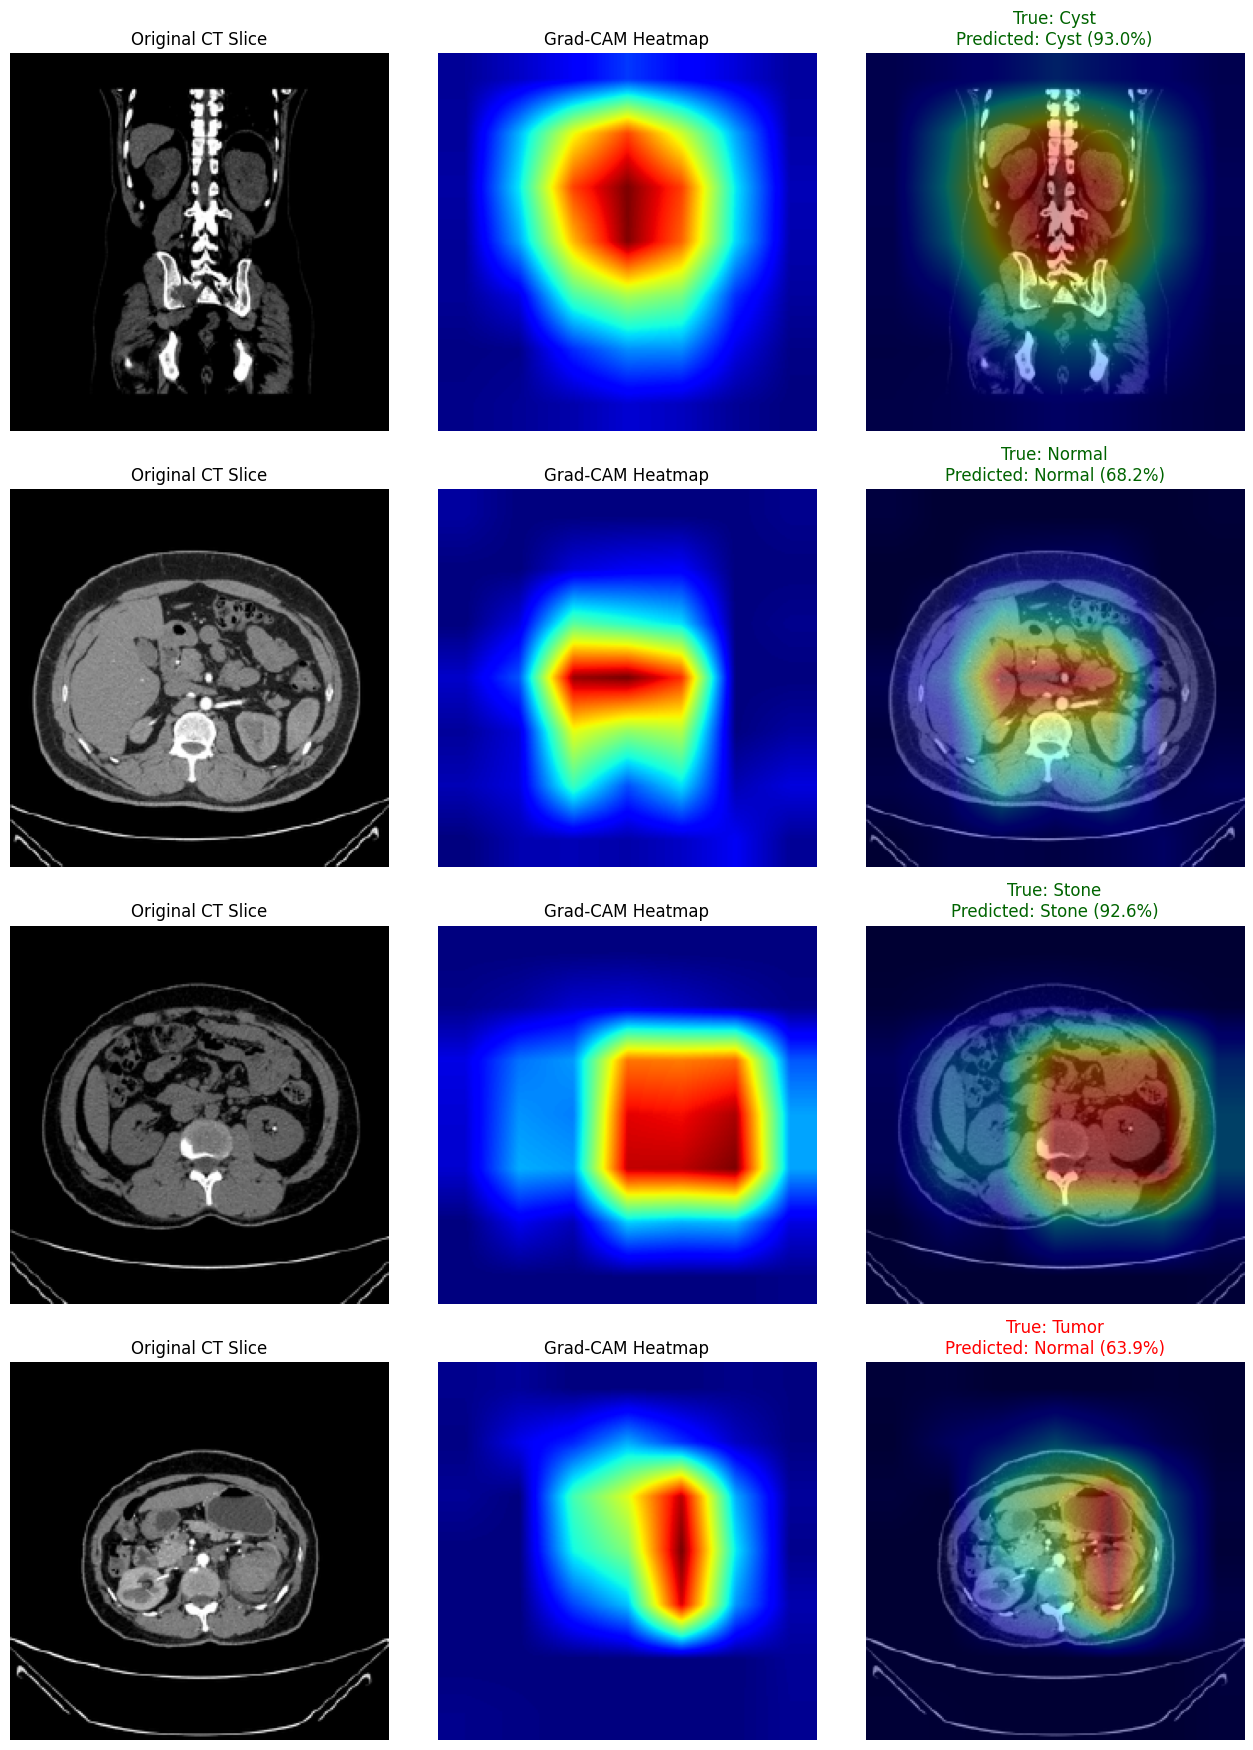

In [34]:
def display_gradcam(img, heatmap, ax_row, title="Grad-CAM", title_color='darkgreen'):
    """img: (H, W, 3) or (H, W, 1) in 0-255."""
    img = np.asarray(img, dtype=np.uint8)
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    h, w = img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))

    # Colorize the heatmap with the jet colormap and superimpose it
    jet_heatmap = matplotlib.colormaps['jet'](np.uint8(255 * heatmap_resized))[..., :3] * 255
    superimposed_img = np.clip(jet_heatmap * 0.4 + img * 0.6, 0, 255).astype(np.uint8)

    ax_row[0].imshow(img)
    ax_row[0].set_title("Original CT Slice")
    ax_row[0].axis('off')

    ax_row[1].imshow(heatmap_resized, cmap='jet')
    ax_row[1].set_title("Grad-CAM Heatmap")
    ax_row[1].axis('off')

    ax_row[2].imshow(superimposed_img)
    ax_row[2].set_title(title, color=title_color)
    ax_row[2].axis('off')
    return superimposed_img


# One random test slice per class, explained by the best model
fig, axes = plt.subplots(num_classes, 3, figsize=(13, 4.4 * num_classes))

for i, class_name in enumerate(class_names):
    idx = random.choice(np.where(y_test == i)[0])
    img_array = np.repeat(X_test[idx:idx + 1], 3, axis=-1).astype('float32')

    heatmap, probs = make_gradcam_heatmap(img_array, best_model)
    pred_idx = int(np.argmax(probs))

    title = f"True: {class_name}\nPredicted: {class_names[pred_idx]} ({probs[pred_idx] * 100:.1f}%)"
    display_gradcam(img_array[0], heatmap, axes[i], title=title,
                    title_color='darkgreen' if pred_idx == i else 'red')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'gradcam_samples.png', dpi=80, bbox_inches='tight')
plt.show()

* **Stone (92.6%):** the heat covers the patient's left kidney (image right), where the small bright stone is. This is the behaviour we want.
* **Normal (68.2%):** the attention is on the central abdomen around the aorta and renal vessels, between the kidneys, rather than on either kidney.
* **Cyst (coronal slice, 93.0%):** a broad central region covering the spine and both kidneys, too coarse to confirm that the cyst itself drives the prediction.
* **Tumor misclassified as Normal (63.9%):** the heat sits on bowel and stomach on the patient's left, away from the abnormal kidney. This shows how a missed tumor happens: the model never focused on the lesion.
* **Overall:** DenseNet121's last feature map is only 7×7, so each cell covers a large part of the abdomen. The maps often include the spine and central vessels, which suggests that global cues (contrast phase, window, body habitus) contribute alongside the kidneys themselves. That fits the intensity differences found in the EDA. **Grad-CAM does not show that the predictions are purely lesion-driven.**

# Ensemble & Production Deployment

### Ensemble Predictions (Soft Voting)
The class probabilities of the four pre-trained architectures are averaged. For each architecture, the checkpoint (Phase 1 or fine-tuned) with the better validation macro-F1 is used.

In [35]:
ensemble_members = []
for arch in ['ResNet50V2', 'EfficientNetV2B0', 'DenseNet121', 'ConvNeXtTiny']:
    candidates = df_results[df_results['Model'].isin([arch, f'{arch}_FT'])]
    candidates = candidates.sort_values(['Val Macro F1', 'Val Loss'], ascending=[False, True])
    ensemble_members.append(candidates.iloc[0]['Model'])
print(f"Ensemble members: {ensemble_members}")

# Average the predictions (Soft Voting)
ensemble_val = np.mean([val_probs[m] for m in ensemble_members], axis=0)
ensemble_preds = np.mean([test_probs[m] for m in ensemble_members], axis=0)
ensemble_classes = ensemble_preds.argmax(axis=1)

print("\n🌟 Ensemble Classification Report 🌟")
print(classification_report(y_test, ensemble_classes, target_names=class_names, digits=3, zero_division=0))

ensemble_metrics = {
    'val_macro_f1': f1_score(y_val, ensemble_val.argmax(1), average='macro'),
    'accuracy': accuracy_score(y_test, ensemble_classes),
    'macro_f1': f1_score(y_test, ensemble_classes, average='macro'),
    'macro_roc_auc': roc_auc_score(y_test, ensemble_preds, multi_class='ovr', average='macro'),
    'log_loss': log_loss(y_test, ensemble_preds, labels=range(num_classes))
}
best_row = df_results.set_index('Model').loc[best_model_name]
print(f"Ensemble      -> val macro-F1 {ensemble_metrics['val_macro_f1']:.4f} | test acc {ensemble_metrics['accuracy']:.4f} | "
      f"test macro-F1 {ensemble_metrics['macro_f1']:.4f} | log-loss {ensemble_metrics['log_loss']:.4f}")
print(f"{best_model_name:13s} -> val macro-F1 {best_row['Val Macro F1']:.4f} | test acc {best_row['Test Accuracy']:.4f} | "
      f"test macro-F1 {best_row['Test Macro F1']:.4f} | log-loss {best_row['Test Loss']:.4f}")

Ensemble members: ['ResNet50V2_FT', 'EfficientNetV2B0_FT', 'DenseNet121_FT', 'ConvNeXtTiny_FT']

🌟 Ensemble Classification Report 🌟
              precision    recall  f1-score   support

        Cyst      0.865     0.976     0.917       493
      Normal      0.865     0.995     0.925       749
       Stone      0.885     0.833     0.859       204
       Tumor      0.966     0.504     0.663       341

    accuracy                          0.877      1787
   macro avg      0.896     0.827     0.841      1787
weighted avg      0.887     0.877     0.865      1787

Ensemble      -> val macro-F1 0.8684 | test acc 0.8774 | test macro-F1 0.8410 | log-loss 0.3964
DenseNet121_FT -> val macro-F1 0.8895 | test acc 0.8942 | test macro-F1 0.8670 | log-loss 0.3480


* **Ensemble on the test set:** soft voting over the four fine-tuned backbones gives **87.7% accuracy / 0.841 macro-F1**, with the **highest macro ROC-AUC of all (0.983)**.
* **It is not selected:** on validation it is below DenseNet121_FT alone (macro-F1 0.868 vs 0.889), and on test it is also lower in accuracy and macro-F1, with worse log-loss (0.40 vs 0.35). Averaging with weaker members pulls the tumor recall down to 0.50. DenseNet121_FT stays the deployed model.

### Custom Inference Function for Production
`kidney_predict(image_path)` wraps the whole path `load → pad → resize → predict → explain`. It accepts any CT image (JPEG/PNG, any size, grayscale or RGB), so it can be called directly from an API (FastAPI / Streamlit).

In [36]:
def kidney_predict(image_path, model=best_model, show=True):
    """End-to-end inference for one CT slice: prediction, confidence, Grad-CAM heatmap."""
    img = load_image(image_path)
    heatmap, probs = make_gradcam_heatmap(img[None], model)
    pred_idx = int(np.argmax(probs))
    predicted_class, confidence = class_names[pred_idx], float(probs[pred_idx] * 100)

    print(f"🩻 Predicted Finding: {predicted_class}")
    print(f"📊 Confidence: {confidence:.2f}%")

    if show:
        fig, axes_row = plt.subplots(1, 3, figsize=(13, 4.4))
        display_gradcam(img, heatmap, axes_row, title=f"{predicted_class} ({confidence:.1f}%)")
        plt.show()

    return {"prediction": predicted_class, "confidence": confidence, "heatmap": heatmap}

# Final Best Model Summary

* **Best model:** DenseNet121, fully fine-tuned (AdamW 3e-5, label smoothing 0.1, strong augmentation), selected on validation macro-F1
* **Input:** CT slice → grayscale → padded to square → 224×224, repeated to 3 channels (0–255, scaled inside the model)
* **Classes:** Cyst, Normal, Stone, Tumor
* **Data:** 11,929 unique slices from 189 scan series; split by **scan**: Train 8,353 (123 scans) | Val 1,789 (30 scans) | Test 1,787 (36 scans)
* **Class imbalance handling:** balanced class weights (Stone × 2.19, Tumor × 1.31) + CT-safe augmentation (no flips)
* **Test metrics (unseen scans):** 89.4% accuracy (scan-level 95% CI 82–96%), 0.867 macro-F1 (CI 0.70–0.91), 0.976 macro ROC-AUC
* **Weak spot:** Tumor recall 0.66 (4 test scans, one largely missed) and Stone recall 0.77
* **Explainability:** Grad-CAM heatmaps; attention is partly on kidneys and partly on central abdomen / spine (flagged caveat)
* **Reliability layer:** Isolation Forest OOD gate (3.2% of real validation slices rejected; 100% of noise, black images, chest X-rays and ECGs rejected) + 75% confidence threshold

# Mock Test

Testing Production Function on True Class: Cyst
--------------------------------------------------
🩻 Predicted Finding: Cyst
📊 Confidence: 93.05%


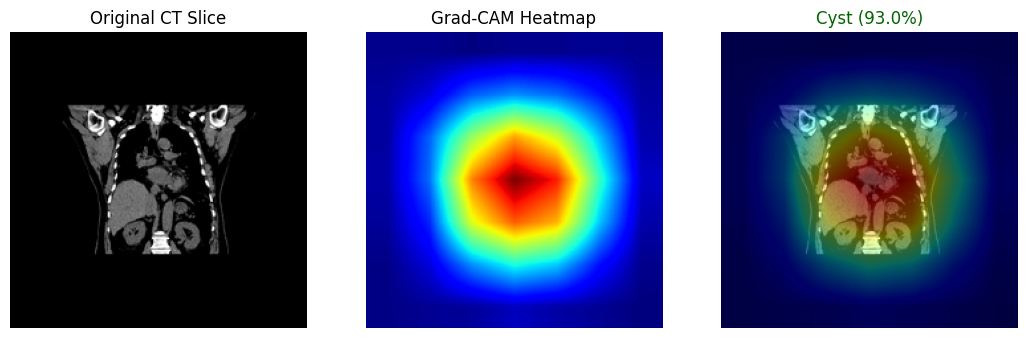

In [37]:
# Pick a random slice from the test set
test_class = random.choice(class_names)
test_img_name = random.choice(os.listdir(test_dir / test_class))
test_img_path = test_dir / test_class / test_img_name

print(f"Testing Production Function on True Class: {test_class}\n{'-' * 50}")
result = kidney_predict(test_img_path)

# Clinical Safety & Out-of-Distribution (OOD) Detection

### Cascaded Kidney CT AI Pipeline

The classifier assumes every input is an abdominal CT slice through the kidneys. Given a chest X-ray, an ECG, a photo or random noise it will still confidently name a kidney finding. A 4-stage cascade guards against this:

| Stage | What | Outcome |
|---|---|---|
| **1. Input validity (OOD gate)** | Isolation Forest or nearest-neighbour distance on the best model's embeddings (chosen on validation) | Not a kidney CT → **Rejected** |
| **2. Classification** | Best model | Probabilities for the 4 classes |
| **3. Confidence check** | Top-class probability < threshold | **Low Confidence – Manual Review** |
| **4. Explainability** | Grad-CAM on the top class + top-3 differential | Heatmap and overlay for the radiologist |

```
CT slice ─► [1] OOD gate ──reject──► "Not a kidney CT slice"
                 │ pass
                 ▼
            [2] Classifier ─► [3] confidence ≥ threshold? ──no──► "Manual review"
                                       │ yes
                                       ▼
                                 [4] Grad-CAM + top-3 ─► report
```

Two Stage 1 detectors are fitted. The lung module used an **Isolation Forest**. The heart ECG module replaced it with a **k-nearest-neighbour** distance gate, because there the Isolation Forest let every noise and blank image through. Neither works everywhere, so both are validated here and a fixed rule picks the one to deploy: it must reject every non-CT input set, and among those that do, the one that wrongly rejects the fewest real **validation** slices wins.

In [38]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
import joblib

print("Setting up Out-of-Distribution (OOD) Detectors...")
gc.collect()
torch.cuda.empty_cache()   # nine models are loaded; release cached blocks before embedding thousands of slices

# Embeddings = output of the GlobalAveragePooling layer of the best model
feature_extractor = keras.Model(inputs=best_model.inputs, outputs=best_model.get_layer('gap').output)


def embed(X, extractor=feature_extractor):
    """X: (N, H, W, 1 or 3) array in 0-255 -> embeddings."""
    X = np.asarray(X)
    if X.shape[-1] == 1:
        X = np.repeat(X, 3, axis=-1)
    return keras.ops.convert_to_numpy(extractor.predict(X.astype('float32'), batch_size=BATCH_SIZE, verbose=0))


print("Extracting training embeddings for the OOD baseline (all training slices, no augmentation)...")
train_embeddings = embed(X_train)

# A. Isolation Forest - the lung module's gate. Contamination assumes ~1% of training slices are unusual
iso_forest = IsolationForest(n_estimators=200, contamination=0.01, random_state=SEED).fit(train_embeddings)

# B. k-nearest-neighbour gate: mean cosine distance to the 5 closest training slices from OTHER scans.
#    (Neighbouring slices of the same scan are near-copies, so they are excluded when calibrating.)
#    Threshold = 99th percentile of that score over the training slices.
OOD_K = 5
unit = lambda E: E / np.linalg.norm(E, axis=1, keepdims=True)
train_series = np.array([series_of[p.relative_to(base_dir).as_posix()] for p in train_paths])
knn_index = NearestNeighbors(n_neighbors=OOD_K).fit(unit(train_embeddings))

calib = []
for s in np.unique(train_series):
    inside = train_series == s
    other = NearestNeighbors(n_neighbors=OOD_K).fit(unit(train_embeddings[~inside]))
    calib.append(other.kneighbors(unit(train_embeddings[inside]))[0].mean(1))
calib = np.concatenate(calib)
knn_gate = {'type': 'knn', 'index': knn_index, 'k': OOD_K, 'threshold': float(np.percentile(calib, 99))}
iso_gate = {'type': 'isolation_forest', 'model': iso_forest}


def knn_ood_score(emb, gate):
    return gate['index'].kneighbors(unit(emb), n_neighbors=gate['k'])[0].mean(1)


def is_ood(emb, gate):
    """True = rejected. Works for both gate types."""
    if gate['type'] == 'isolation_forest':
        return gate['model'].predict(emb) == -1
    return knn_ood_score(emb, gate) > gate['threshold']


print(f"✅ Both gates fitted on {len(train_embeddings)} CT embeddings ({train_embeddings.shape[1]} dims). "
      f"kNN threshold = {knn_gate['threshold']:.4f}")

Setting up Out-of-Distribution (OOD) Detectors...
Extracting training embeddings for the OOD baseline (all training slices, no augmentation)...


✅ Both gates fitted on 8353 CT embeddings (1024 dims). kNN threshold = 0.5272


### Validating the OOD Gate
Both gates are checked on held-out CT slices and on inputs that must be rejected. These include wrong uploads from the other modules of this project: **chest X-rays** (lung dataset) and **ECG printouts** (heart dataset), plus random noise, all-black images, and grey speckle on a black background.

In [39]:
rng_ood = np.random.default_rng(SEED)
ood_sets = {
    'Validation CT slices': X_val,
    'Test CT slices': X_test,
    'Random noise': rng_ood.integers(0, 256, (50,) + INPUT_SHAPE).astype('float32'),
    'All-black image': np.zeros((10,) + INPUT_SHAPE, dtype='float32'),
    'Grey speckle on black': np.clip(np.abs(rng_ood.normal(0, 70, (20,) + IMG_SIZE + (1,))), 0, 255).repeat(3, -1).astype('float32'),
}

def sample_images(root, n=60):
    paths = [p for p in Path(root).rglob('*') if p.suffix.lower() in ('.png', '.jpg', '.jpeg')]
    paths = random.Random(SEED).sample(paths, min(n, len(paths)))
    return paths, np.stack([load_image(p) for p in paths]) if paths else None

# Chest X-rays from the lung dataset and ECG printouts from the heart module, if on this machine
xray_root = Path('E:/Lung_Xray/test')
ecg_root = Path('../../../heart/image_based/data/test')
if xray_root.exists():
    xray_paths, ood_sets['Chest X-rays (lung dataset)'] = sample_images(xray_root)
if ecg_root.exists():
    ecg_paths, ood_sets['ECG printouts (heart dataset)'] = sample_images(ecg_root)

rows = []
for set_name, X in ood_sets.items():
    emb = embed(X)
    rows.append({'Input set': set_name, 'Images': len(X),
                 'Isolation Forest rejected %': round(100 * is_ood(emb, iso_gate).mean(), 1),
                 'kNN gate rejected %': round(100 * is_ood(emb, knn_gate).mean(), 1)})
ood_report = pd.DataFrame(rows)
display(ood_report)

# Selection rule: reject >= 99% of every non-CT set, then fewest false rejections on the VALIDATION slices
gates = {'Isolation Forest': (iso_gate, 'Isolation Forest rejected %'), 'kNN gate': (knn_gate, 'kNN gate rejected %')}
non_ct = ood_report[~ood_report['Input set'].str.contains('CT slices')]
val_row = ood_report[ood_report['Input set'] == 'Validation CT slices'].iloc[0]
eligible = [g for g, (_, col) in gates.items() if (non_ct[col] >= 99).all()]
chosen_gate_name = min(eligible, key=lambda g: val_row[gates[g][1]])
deployed_gate, deployed_col = gates[chosen_gate_name]

joblib.dump(deployed_gate, MODELS_DIR / 'kidney_ct_ood_detector.joblib')
print(f"Deployed Stage 1 gate: {chosen_gate_name} "
      f"(rejects {val_row[deployed_col]:.1f}% of validation CT slices) -> models/kidney_ct_ood_detector.joblib")

,Input set,Images,Isolation Forest rejected %,kNN gate rejected %
0,Validation CT slices,1789,3.2,7.3
1,Test CT slices,1787,3.6,19.4
2,Random noise,50,100.0,100.0
3,All-black image,10,100.0,100.0
4,Grey speckle on black,20,100.0,100.0
5,Chest X-rays (lung dataset),60,100.0,100.0
6,ECG printouts (heart dataset),60,100.0,100.0


Deployed Stage 1 gate: Isolation Forest (rejects 3.2% of validation CT slices) -> models/kidney_ct_ood_detector.joblib


* **Both gates reject every non-CT input** (noise, black images, speckle, chest X-rays, ECG printouts: 100%).
* **They differ on real CT slices:** the Isolation Forest wrongly rejects **3.2%** of validation slices, the kNN gate **7.3%**, and on test the kNN gate rejects **19.4%**. After full fine-tuning the model has memorised its training scans (100% training accuracy), so training embeddings sit much closer together than embeddings of new scans, and a distance threshold calibrated on training data ends up too tight.
* **Rule result: the Isolation Forest is deployed** (`models/kidney_ct_ood_detector.joblib`). On the untouched test set it rejects **3.6%** of real slices.
* This is the opposite of the heart ECG module, where the Isolation Forest failed and the kNN gate worked. Neither detector is universally better, which is why the choice is made by a rule on validation data, not by habit.

### Choosing the Confidence Threshold
The threshold is set on the **validation** set: for each candidate, what share of slices is accepted automatically (coverage), and how accurate are the accepted and the flagged ones?

In [40]:
val_best = val_probs[best_model_name]
val_conf, val_correct = val_best.max(1), val_best.argmax(1) == y_val

rows = []
for t in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
    accepted = val_conf >= t
    rows.append({'Threshold': t,
                 'Coverage': accepted.mean(),
                 'Accuracy (accepted)': val_correct[accepted].mean() if accepted.any() else np.nan,
                 'Flagged': int((~accepted).sum()),
                 'Accuracy (flagged)': val_correct[~accepted].mean() if (~accepted).any() else np.nan})
display(pd.DataFrame(rows).round(3))

,Threshold,Coverage,Accuracy (accepted),Flagged,Accuracy (flagged)
0,0.50,0.982,0.920,32,0.438
1,0.60,0.949,0.932,91,0.527
2,0.70,0.907,0.952,167,0.515
3,0.75,0.868,0.966,237,0.549
4,0.80,0.834,0.976,297,0.586
5,0.90,0.594,0.996,726,0.787
6,0.95,0.070,1.000,1664,0.904


In [41]:
CONFIDENCE_THRESHOLD = 0.75   # same default as the lung module

test_conf = Y_pred.max(1)
test_accepted = test_conf >= CONFIDENCE_THRESHOLD
test_correct = Y_pred.argmax(1) == y_test
confidence_coverage = {
    'threshold': CONFIDENCE_THRESHOLD,
    'coverage': float(test_accepted.mean()),
    'accuracy_accepted': float(test_correct[test_accepted].mean()) if test_accepted.any() else None,
    'accuracy_flagged': float(test_correct[~test_accepted].mean()) if (~test_accepted).any() else None,
}
print(f"Test set at threshold {CONFIDENCE_THRESHOLD}: {confidence_coverage}")

Test set at threshold 0.75: {'threshold': 0.75, 'coverage': 0.8130945719082261, 'accuracy_accepted': 0.9628355127322781, 'accuracy_flagged': 0.5958083832335329}


* On validation, **0.75** accepts 87% of slices with **96.6%** accuracy, while the flagged 13% are only 55% correct. The threshold separates reliable predictions from unreliable ones, so the lung module's default is kept.
* On the **test** set the same threshold accepts **81.3%** of slices, and those are **96.3%** correct. The flagged 19% are 59.6% correct and go to a radiologist.
* 0.90 would push accepted accuracy to 99.6% (validation), but only 59% of slices would be reported automatically. That trade-off may suit a screening setting where a radiologist reads everything flagged.
* The pipeline demo below shows Stage 3 at work: a **Stone** slice misread as Cyst at 59% confidence is flagged for review instead of being reported.

### Clinical-style Final Function

In [42]:
def predict_kidney_ct(image_path, model=best_model, extractor=feature_extractor, gate=deployed_gate,
                      threshold=CONFIDENCE_THRESHOLD * 100, show=True):
    print(f"\n{'=' * 60}")
    print(f"🩻 CLINICAL AI PIPELINE REPORT")
    print(f"File: {os.path.basename(str(image_path))}")
    print(f"{'=' * 60}")

    # Load and Preprocess
    try:
        img = load_image(image_path)
    except Exception as e:
        print(f"❌ ERROR: Failed to load image. {e}")
        return {'status': 'Error', 'error': str(e)}
    img_array = img[None]

    # Stage 1: Input Validity (OOD Check)
    if is_ood(embed(img_array, extractor), gate)[0]:
        print("🚨 [STAGE 1] OUT-OF-DISTRIBUTION DETECTED")
        print("   Status: REJECTED")
        print("   Reason: This image does not match the embedding space of kidney CT slices.")
        print("   Action: Please upload an axial or coronal abdominal CT slice through the kidneys.\n")
        return {'status': 'Rejected - Not a kidney CT', 'anomaly_flagged': True}   # halt pipeline
    print("✅ [STAGE 1] Input Validation: PASSED (In-distribution)")

    # Stage 2: Disease Classification (+ Stage 4 heatmap from the same forward pass)
    heatmap, preds = make_gradcam_heatmap(img_array, model)
    top_3_indices = np.argsort(preds)[-3:][::-1]
    top_3 = [(class_names[i], float(preds[i] * 100)) for i in top_3_indices]
    primary_pred, primary_conf = top_3[0]
    print(f"\n🔬 [STAGE 2] Primary Finding: {primary_pred}")

    # Stage 3: Confidence Check
    if primary_conf < threshold:
        print(f"⚠️ [STAGE 3] Confidence: {primary_conf:.2f}% (Below {threshold:.0f}% threshold)")
        print("   Status: LOW CONFIDENCE - FLAG FOR MANUAL REVIEW")
        status = 'Low Confidence - Manual Review'
    else:
        print(f"✅ [STAGE 3] Confidence: {primary_conf:.2f}%")
        print("   Status: ACCEPTED")
        status = 'Accepted'

    print("\n📊 Top-3 Probabilities:")
    for cls, prob in top_3:
        print(f"   - {cls:8s}: {prob:.2f}%")

    # Stage 4: Explainability
    print("\n🧠 [STAGE 4] Explainability Map (Grad-CAM) generated.")
    overlay = None
    if show:
        fig, axes_row = plt.subplots(1, 3, figsize=(13, 4.4))
        overlay = display_gradcam(img, heatmap, axes_row, title=f"Pred: {primary_pred} ({primary_conf:.1f}%)\nStatus: {status}")
        plt.show()

    return {'status': status, 'anomaly_flagged': False, 'prediction': primary_pred,
            'confidence': primary_conf / 100, 'probabilities': dict(zip(class_names, map(float, preds))),
            'top_3': top_3, 'heatmap': heatmap, 'overlay': overlay}

### Testing the Pipeline
The pipeline is run on a real test CT slice, a random-noise image, a chest X-ray and an ECG printout, to see the OOD gate in action.

Testing on a valid CT slice from the test set (Stone):

🩻 CLINICAL AI PIPELINE REPORT
File: Stone-1330.png
✅ [STAGE 1] Input Validation: PASSED (In-distribution)



🔬 [STAGE 2] Primary Finding: Cyst
⚠️ [STAGE 3] Confidence: 59.03% (Below 75% threshold)
   Status: LOW CONFIDENCE - FLAG FOR MANUAL REVIEW

📊 Top-3 Probabilities:
   - Cyst    : 59.03%
   - Stone   : 37.55%
   - Normal  : 1.93%

🧠 [STAGE 4] Explainability Map (Grad-CAM) generated.


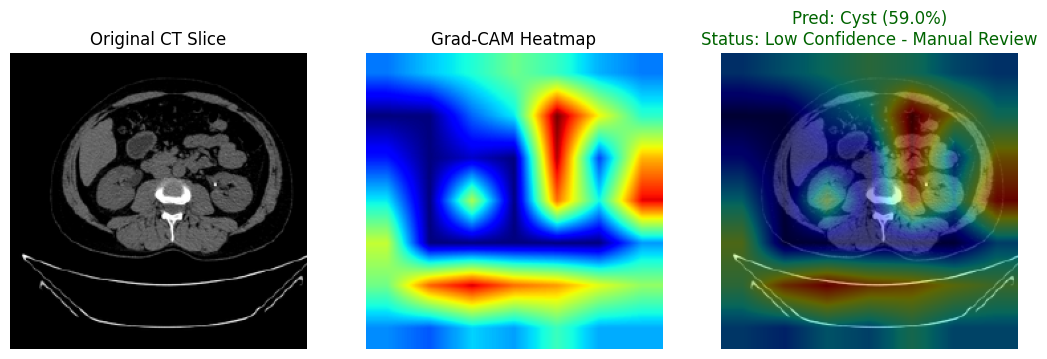



Testing on an invalid image (Random Noise):

🩻 CLINICAL AI PIPELINE REPORT
File: tmps5chsqaa.png


🚨 [STAGE 1] OUT-OF-DISTRIBUTION DETECTED
   Status: REJECTED
   Reason: This image does not match the embedding space of kidney CT slices.
   Action: Please upload an axial or coronal abdominal CT slice through the kidneys.



Testing on a chest X-ray (wrong modality):

🩻 CLINICAL AI PIPELINE REPORT
File: Pneumonia-Viral (897).jpg


🚨 [STAGE 1] OUT-OF-DISTRIBUTION DETECTED
   Status: REJECTED
   Reason: This image does not match the embedding space of kidney CT slices.
   Action: Please upload an axial or coronal abdominal CT slice through the kidneys.



Testing on an ECG printout (wrong modality):

🩻 CLINICAL AI PIPELINE REPORT
File: HB(193).png


🚨 [STAGE 1] OUT-OF-DISTRIBUTION DETECTED
   Status: REJECTED
   Reason: This image does not match the embedding space of kidney CT slices.
   Action: Please upload an axial or coronal abdominal CT slice through the kidneys.



In [43]:
import tempfile

# 1. A valid CT slice from the test set
test_class = random.choice(class_names)
test_img_path = test_dir / test_class / random.choice(os.listdir(test_dir / test_class))
print(f"Testing on a valid CT slice from the test set ({test_class}):")
_ = predict_kidney_ct(test_img_path)

# 2. An invalid input: random RGB noise
print("\n\nTesting on an invalid image (Random Noise):")
noise_arr = np.random.randint(0, 256, (512, 512, 3), dtype=np.uint8)
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_file:
    noise_img_path = temp_file.name
Image.fromarray(noise_arr).save(noise_img_path)
_ = predict_kidney_ct(noise_img_path)
os.remove(noise_img_path)

# 3. The wrong organ / modality: a chest X-ray and an ECG
if xray_root.exists():
    print("\n\nTesting on a chest X-ray (wrong modality):")
    _ = predict_kidney_ct(xray_paths[0])
if ecg_root.exists():
    print("\n\nTesting on an ECG printout (wrong modality):")
    _ = predict_kidney_ct(ecg_paths[0])

### Save Deployment Metadata
Everything a serving script needs besides the `.keras` file: class order, preprocessing, the chosen model, the threshold, and the measured test metrics.

In [44]:
best_test = df_results.set_index('Model').loc[best_model_name]
metadata = {
    'class_names': class_names,
    'img_size': list(IMG_SIZE),
    'preprocessing': 'grayscale; pad to square with black; resize to 224x224 (BOX); repeat to 3 channels; float 0-255 - each model rescales internally',
    'best_model': best_model_name,
    'selection': 'highest validation macro-F1, then lowest validation loss',
    'split': 'scan-series level (no CT series in more than one split)',
    'ensemble_members': ensemble_members,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'test_metrics': {
        'accuracy': float(best_test['Test Accuracy']),
        'macro_f1': float(best_test['Test Macro F1']),
        'macro_roc_auc': float(best_test['Test Macro ROC-AUC']),
        'log_loss': float(best_test['Test Loss']),
        'accuracy_95ci_scan_bootstrap': [float(v) for v in acc_ci],
        'macro_f1_95ci_scan_bootstrap': [float(v) for v in f1_ci],
    },
    'ensemble_test_metrics': {k: float(v) for k, v in ensemble_metrics.items()},
    'confidence_coverage': confidence_coverage,
    'ood_gate': {'method': chosen_gate_name,
                 'selection': 'rejects >= 99% of every non-CT set, then fewest false rejections of validation CT slices',
                 'rejected': {row['Input set']: row[deployed_col] / 100 for _, row in ood_report.iterrows()},
                 'alternative_rejected': {row['Input set']: row[[c for g, (_, c) in gates.items() if g != chosen_gate_name][0]] / 100
                                          for _, row in ood_report.iterrows()}},
    'dataset': {'unique_slices': int(len(manifest)), 'scan_series': int(manifest['series_id'].nunique()),
                'train': int(len(X_train)), 'val': int(len(X_val)), 'test': int(len(X_test))},
    'leakage_demo_1nn_accuracy': {'random_split': float(acc_random), 'series_split': float(acc_series)},
}
(MODELS_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2))
print(json.dumps(metadata, indent=2))

{
  "class_names": [
    "Cyst",
    "Normal",
    "Stone",
    "Tumor"
  ],
  "img_size": [
    224,
    224
  ],
  "preprocessing": "grayscale; pad to square with black; resize to 224x224 (BOX); repeat to 3 channels; float 0-255 - each model rescales internally",
  "best_model": "DenseNet121_FT",
  "selection": "highest validation macro-F1, then lowest validation loss",
  "split": "scan-series level (no CT series in more than one split)",
  "ensemble_members": [
    "ResNet50V2_FT",
    "EfficientNetV2B0_FT",
    "DenseNet121_FT",
    "ConvNeXtTiny_FT"
  ],
  "confidence_threshold": 0.75,
  "test_metrics": {
    "accuracy": 0.8942361499720202,
    "macro_f1": 0.867016310301131,
    "macro_roc_auc": 0.9758629661028513,
    "log_loss": 0.3480222960806383,
    "accuracy_95ci_scan_bootstrap": [
      0.8214178760354944,
      0.95865221473335
    ],
    "macro_f1_95ci_scan_bootstrap": [
      0.7006716911345909,
      0.9120612468626422
    ]
  },
  "ensemble_test_metrics": {
    "val_ma

# Conclusion
This project built a leakage-free, explainable and safety-gated computer-vision pipeline that classifies kidney CT slices into Cyst, Normal, Stone and Tumor. It follows the structure of the lung X-ray module, but on this dataset getting the **evaluation** right mattered more than the model choice.

**Key Achievements & Methodologies:**
* **Honest Evaluation:** Removed 517 exact duplicates and showed that the 12,446 images are consecutive slices of only 189 CT scans. Split by scan, not by image: a memorising 1-NN classifier drops from **100% to 45%** when scans are held out, which exposes how random splits inflate the ~99% results common for this dataset.
* **Preprocessing & Augmentation:** Aspect-preserving pad-to-square, 224×224 grayscale→RGB, strong CT-safe augmentation on the GPU (no flips), and balanced class weights.
* **Model Optimization:** Compared a Custom CNN, ResNet50V2, EfficientNetV2B0, DenseNet121 and **ConvNeXtTiny**. The lung recipe (frozen head + 30-layer fine-tune) failed on unseen scans (best validation macro-F1 0.59). Replacing it with **full fine-tuning** (AdamW, weight decay, label smoothing), chosen on validation data only, lifted every backbone by 20–30 points. **DenseNet121_FT** was selected and reached **89.4% accuracy, 0.867 macro-F1 and 0.976 ROC-AUC** on 36 unseen scans.
* **Uncertainty Reporting:** Scan-level bootstrap intervals and per-scan accuracy show where the model is dependable (Cyst, Normal) and where it is not (Tumor, Stone).
* **Visual Explainability (Grad-CAM):** A PyTorch-autograd Grad-CAM on every prediction. For stones it points at the stone-bearing kidney; in other cases it spreads over the central abdomen, which is reported as a limitation rather than hidden.
* **Cascaded Clinical Safety Pipeline:**
  1. **Input Validation (OOD Detection):** Isolation Forest and kNN gates were compared with a fixed validation rule. The deployed Isolation Forest rejects 100% of noise, black images, chest X-rays and ECG printouts, and 3.6% of real test slices.
  2. **Disease Classification:** top-3 differential for the radiologist.
  3. **Confidence Thresholding:** at 75%, 81% of test slices are reported automatically with 96% accuracy; the rest go to manual review.
  4. **Explainability:** a Grad-CAM overlay is attached to every accepted report.

**Limitations:**
* **Few patients:** 189 scans in total and only **4 tumor scans in the test set**. Tumor recall (0.66) and its confidence interval rest on very few patients.
* **Acquisition shortcuts:** the classes differ in contrast phase and display window (see the intensity histograms). Part of what the model learned may be *how* a scan was acquired, not *what* it shows. A dataset with contrast and non-contrast scans in every class would be needed to rule this out.
* **Single source:** all scans come from hospitals in Dhaka, exported as windowed JPEGs rather than raw Hounsfield-unit DICOMs. Other scanners, windows or reconstruction kernels are untested.
* **Slice-level, not patient-level:** a radiologist reads a whole scan. Aggregating slice predictions per series would be the natural clinical output.

**Future Work / Next Steps:**
* **Series-level diagnosis:** combine the slice probabilities of a whole scan (e.g. max or attention pooling), turning the per-scan table above into a patient-level result.
* **Better data:** KiTS23 (kidney tumor CT volumes with segmentations, raw HU) for a multi-centre tumor test set and for lesion-level localisation instead of coarse Grad-CAM.
* **Higher resolution for stones:** stones shrink to 1–2 pixels at 224×224. A 384–512 px input or a kidney-crop stage would help Stone recall.
* **Clinical UI Integration:** wrap `predict_kidney_ct` into the project's Streamlit/FastAPI front end next to `predict_lung_xray` and `predict_heart_ecg`.